## Graph Theory

Graph Theory is one of the fundamental mathematical concepts in Artificial Intelligence. Unlike graphs as a data structure, which focus on implementation and storage, Graph Theory studies the mathematical properties and relationships between objects represented as graphs.

Many AI algorithms rely on graph theory to model real-world problems such as route planning, social networks, recommendation systems, dependency analysis, and knowledge representation. Understanding these concepts provides the foundation for search algorithms, optimization, and machine learning techniques.

### 0. Graph

A graph is a mathematical structure consisting of vertices (nodes) and edges (links).

Vertices (Nodes): Represent the objects or entities in a graph.
Edges: Represent the relationships or connections between pairs of vertices.

A graph is commonly written as $G=(V,E)$

Where: $V$ is the set of vertices. $E$ is the set of edges.

#### 1. Representing a Graph with NetworkX

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

This graph contains four vertices and three edges.

- Vertices: $A, B, C, D$.
- Edges: $(A, B), (A, C), (B, D)$

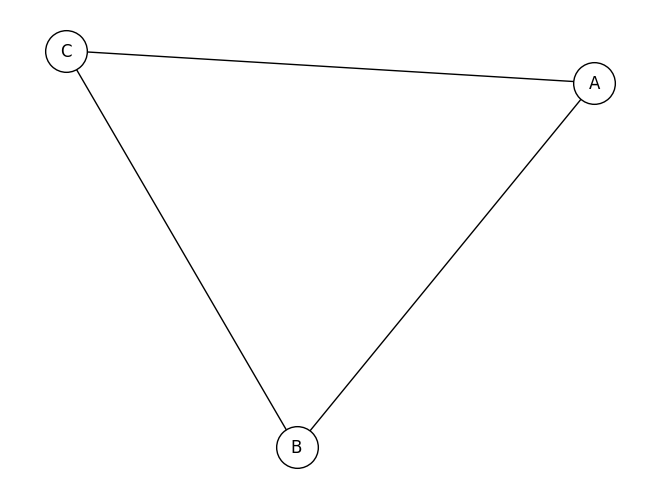

In [ ]:
# Create an empty graph
G = nx.Graph()

# Add vertices
G.add_nodes_from(["A", "B", "C"])

# Add edges
G.add_edges_from([
    ("A", "B"),
    ("A", "C"),
    ("B", "C")
])

# Draw the graph
nx.draw(
    G,
    with_labels=True,
    node_color="white",
    node_size=900,
    font_size=12,
    edgecolors='black',
    linewidths=1
)

plt.show()

### 2. Basic Types of Graphs

NetworkX provides different graph classes to represent various types of graphs. In this section, we will use a **default graph containing 5 vertices and 6 edges** and modify it to illustrate each graph type.

In [ ]:
# Default graph
edges = [
    ("A", "B"),
    ("A", "C"),
    ("B", "C"),
    ("B", "D"),
    ("C", "E"),
    ("D", "E")
]

#### Simple Graph

A **simple graph** is a graph in which:

- Every edge connects two different vertices.
- There is at most one edge between any pair of vertices.
- Self-loops (rings) are not allowed.

A simple graph is the most commonly used graph in graph theory.

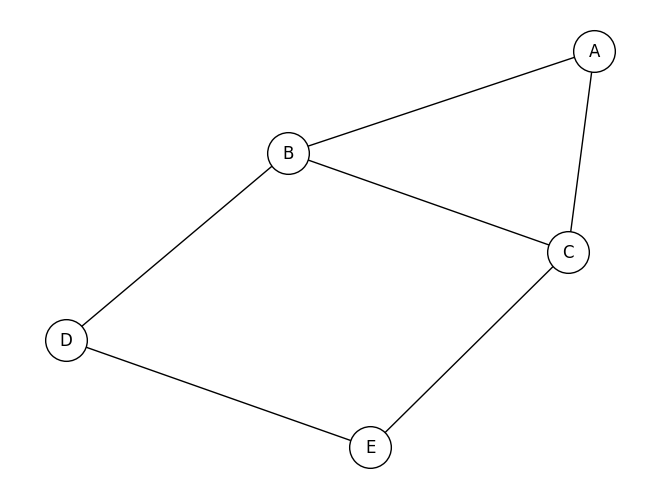

In [ ]:
G = nx.Graph()
G.add_edges_from(edges)

nx.draw(
    G,
    with_labels=True,
    node_size=900,
    node_color="white",
    edgecolors='black',
    linewidths=1
)

plt.show()

#### Multigraph

A **multigraph** allows **multiple edges** between the same pair of vertices.

If there are (m) different edges connecting the same two vertices, they are called an **m-multiple edge**.

NetworkX represents a multigraph using the MultiGraph class.

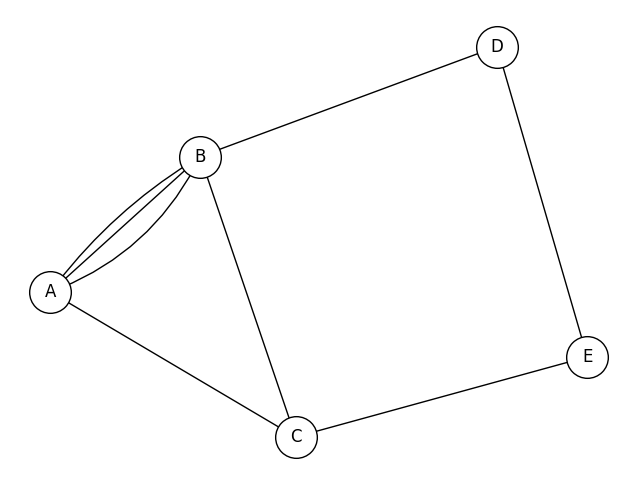

In [ ]:
G = nx.MultiGraph()

G.add_edges_from(edges)

# Add duplicate edges
G.add_edge("A", "B")
G.add_edge("A", "B")

# Get positions for the nodes
pos = nx.spring_layout(G)

plt.figure(figsize=(8, 6)) # Set a reasonable figure size for better visualization

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=900, node_color="white", edgecolors='black', linewidths=1)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=12)

# Draw edges with curvature to distinguish parallel edges
edge_offsets = {} # To keep track of how many times we've drawn an edge between a pair
for u, v, key in G.edges(keys=True):
    # Sort the pair to treat (u,v) and (v,u) symmetrically for offsets
    node_pair = tuple(sorted((u, v)))

    if node_pair not in edge_offsets:
        edge_offsets[node_pair] = 0
    else:
        edge_offsets[node_pair] += 1

    # Determine curvature:
    # The first edge (offset 0) between a pair is straight.
    # Subsequent edges alternate curvature direction and increase magnitude.

    rad_magnitude = 0.1 * ((edge_offsets[node_pair] // 2) + 1)
    rad = rad_magnitude if edge_offsets[node_pair] % 2 == 0 else -rad_magnitude

    connection_style = f'arc3,rad={rad}' if edge_offsets[node_pair] > 0 else 'arc3,rad=0'

    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(u, v, key)], # Draw one edge at a time using its unique key
        connectionstyle=connection_style,
        edge_color="black"
    )

plt.axis('off') # Hide axes
plt.show()

#### Pseudograph

A **pseudograph** allows:

- Self-loops (rings).
- Multiple edges between the same pair of vertices.

NetworkX does not have a separate `PseudoGraph` class. A `MultiGraph` supports both multiple edges and self-loops.

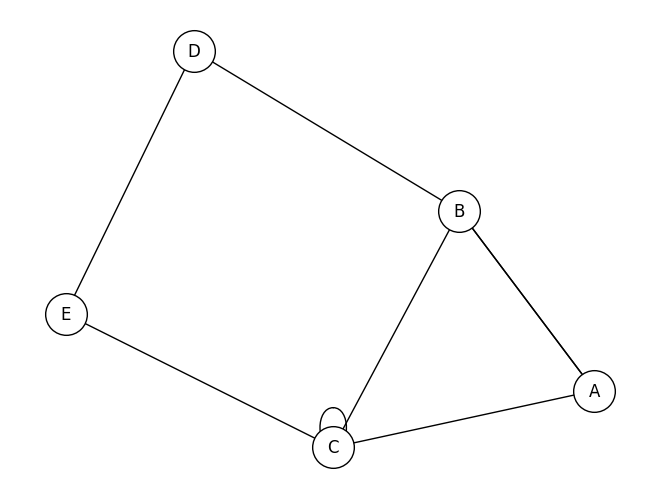

In [ ]:
G = nx.MultiGraph()

G.add_edges_from(edges)

# Multiple edge
G.add_edge("A", "B")

# Self-loop
G.add_edge("C", "C")

nx.draw(
    G,
    with_labels=True,
    node_size=900,
    node_color="white",
    edgecolors='black',
    linewidths=1
)

plt.show()

#### Undirected Graph

An **undirected graph** has edges without direction.

This means that an edge connecting **A** and **B** can be traversed in both directions.

For example, $A → B$ and $B → A$ represent the same edge.

NetworkX represents an undirected graph using `Graph()`.

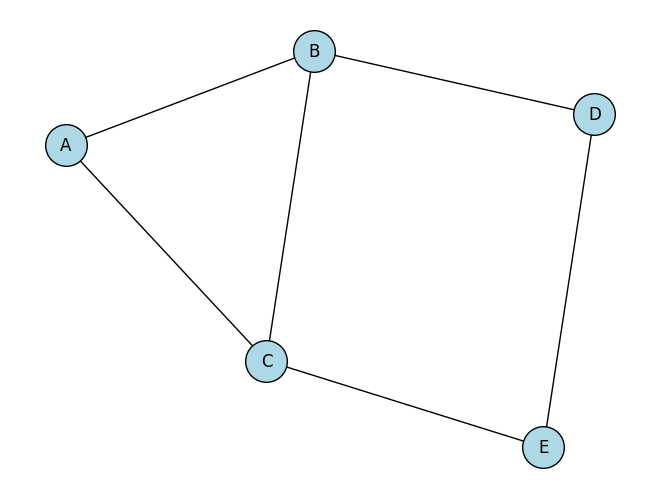

In [ ]:
G = nx.Graph()

G.add_edges_from(edges)

nx.draw(
    G,
    with_labels=True,
    node_size=900,
    node_color="lightblue",
    edgecolors='black',
    linewidths=1
)

plt.show()

#### Directed Graph

A **directed graph (digraph)** assigns a direction to every edge. Each edge is represented as an ordered pair $(u,v)$ meaning the edge starts at **$u$** and ends at **$v$**.

Unlike undirected graphs, the edge $(A, B)$ is different from $(B, A)$.

NetworkX uses the `DiGraph` class.

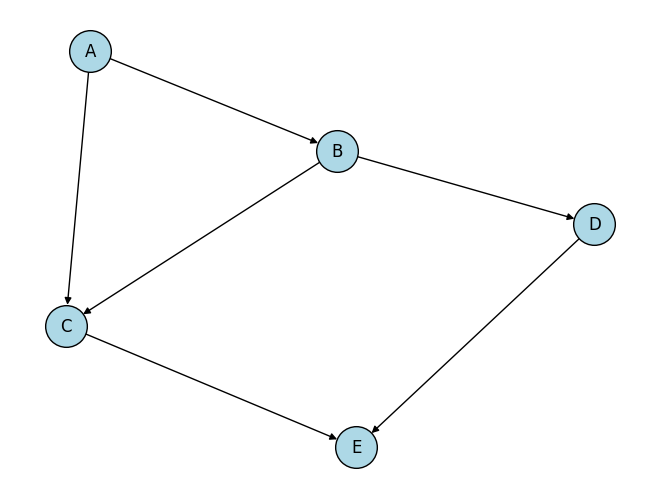

In [ ]:
DG = nx.DiGraph()

DG.add_edges_from([
    ("A", "B"),
    ("A", "C"),
    ("B", "C"),
    ("B", "D"),
    ("C", "E"),
    ("D", "E")
])

nx.draw(
    DG,
    with_labels=True,
    node_size=900,
    node_color="lightblue",
    edgecolors='black',
    linewidths=1,
    arrows=True
)

plt.show()

#### Simple Directed Graph

A **simple directed graph** is a directed graph that:

- Has no self-loops.
- Has no multiple directed edges.
- Contains at most one edge from one vertex to another.

This is represented using `DiGraph`.

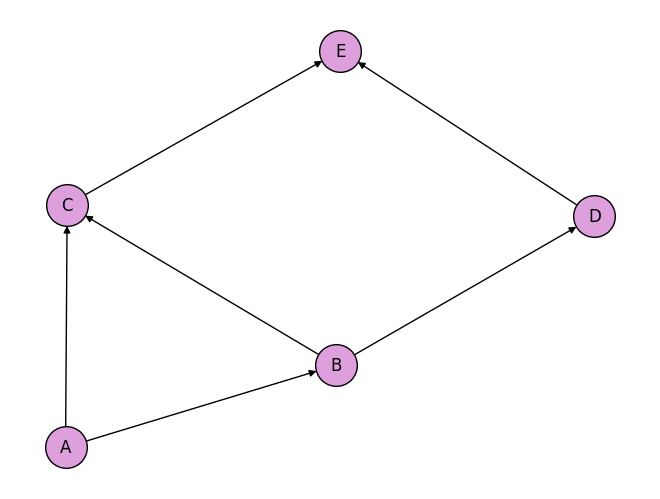

In [ ]:
G = nx.DiGraph()

G.add_edges_from([
    ("A", "B"),
    ("A", "C"),
    ("B", "C"),
    ("B", "D"),
    ("C", "E"),
    ("D", "E")
])

nx.draw(
    G,
    with_labels=True,
    node_size=900,
    node_color="plum",
    arrows=True,
    edgecolors='black',
    linewidths=1,
)

plt.show()

#### Multi Directed Graph

A **multi directed graph** (or directed multigraph) allows multiple directed edges between the same ordered pair of vertices.

NetworkX represents this graph using `MultiDiGraph`.

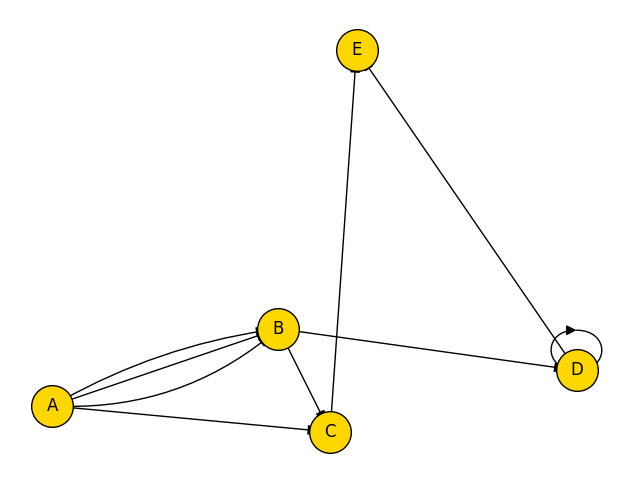

In [ ]:
G = nx.MultiDiGraph()

G.add_edges_from([
    ("A", "B"),
    ("A", "C"),
    ("B", "C"),
    ("B", "D"),
    ("C", "E"),
    ("D", "E")
])

# Multiple directed edges
G.add_edge("A", "B")
G.add_edge("A", "B")

# Self-loop
G.add_edge("D", "D")

# Get positions for the nodes
pos = nx.spring_layout(G)

plt.figure(figsize=(8, 6)) # Set a reasonable figure size for better visualization

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=900, node_color="gold", edgecolors='black', linewidths=1)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=12)

# Draw edges with curvature to distinguish parallel edges and self-loops
edge_offsets = {}
for u, v, key in G.edges(keys=True):
    # For self-loops, we use a different key to ensure they are curved
    if u == v:
        node_pair = (u, v, 'self_loop')
    else:
        # Sort the pair to treat (u,v) and (v,u) symmetrically for offsets for parallel edges
        node_pair = tuple(sorted((u, v)))

    if node_pair not in edge_offsets:
        edge_offsets[node_pair] = 0
    else:
        edge_offsets[node_pair] += 1

    # Determine curvature:
    # The first edge (offset 0) between a pair is straight.
    # Subsequent edges alternate curvature direction and increase magnitude.

    rad_magnitude = 0.1 * ((edge_offsets[node_pair] // 2) + 1)
    rad = rad_magnitude if edge_offsets[node_pair] % 2 == 0 else -rad_magnitude

    if u == v: # Special handling for self-loops
        connection_style = f'arc3,rad={0.3 + rad_magnitude}' # Increase rad for self-loops
    elif edge_offsets[node_pair] > 0:
        connection_style = f'arc3,rad={rad}'
    else:
        connection_style = 'arc3,rad=0'

    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(u, v, key)], # Draw one edge at a time using its unique key
        connectionstyle=connection_style,
        edge_color="black",
        arrows=True,
        arrowsize=15
    )

plt.axis('off') # Hide axes
plt.show()

### 3. Special Types of Graphs

Besides the basic graph types, graph theory defines several special graphs with unique structures and properties.

#### Complete Graph

A **complete graph** is a simple graph in which **every pair of distinct vertices is connected by exactly one edge**.

A complete graph with (n) vertices is denoted by $K_n$. The total number of edges is $\frac{n(n-1)}{2}$

NetworkX provides a built-in function to generate a complete graph.

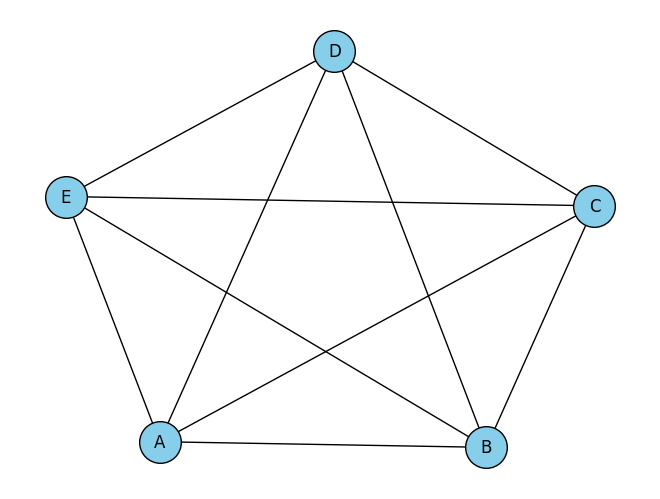

In [ ]:
G = nx.complete_graph(5)

mapping = {0:"A",1:"B",2:"C",3:"D",4:"E"}
G = nx.relabel_nodes(G, mapping)

nx.draw(
    G,
    with_labels=True,
    node_size=900,
    node_color="skyblue",
    edgecolors='black',
    linewidths=1,
)

plt.show()

#### Cycle Graph

A **cycle graph** forms a closed loop where every vertex is connected to exactly two neighboring vertices.

A cycle graph with $n$ vertices is denoted by $C_n,\ n\ge3$. Every vertex belongs to a single cycle, forming the shape of a polygon.

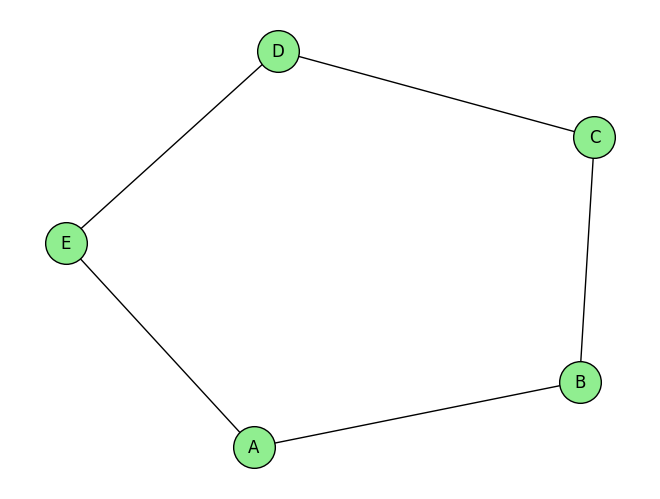

In [ ]:
G = nx.cycle_graph(5)

mapping = {0:"A",1:"B",2:"C",3:"D",4:"E"}
G = nx.relabel_nodes(G, mapping)

nx.draw(
    G,
    with_labels=True,
    node_size=900,
    node_color="lightgreen",
    edgecolors='black',
    linewidths=1,
)

plt.show()

#### Wheel Graph

A **wheel graph** is constructed by adding one central vertex to a cycle graph and connecting the center to every vertex on the cycle.

A wheel graph with $n$ vertices is denoted by $W_n$.

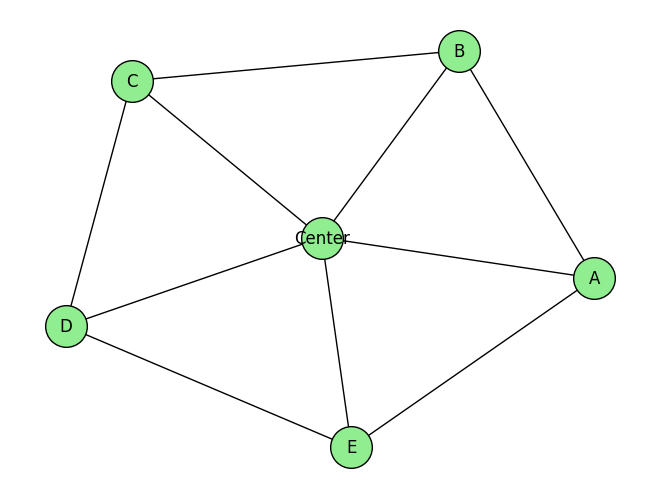

In [ ]:
G = nx.wheel_graph(6)

mapping = {
    0:"Center",
    1:"A",
    2:"B",
    3:"C",
    4:"D",
    5:"E"
}

G = nx.relabel_nodes(G, mapping)

nx.draw(
    G,
    with_labels=True,
    node_size=900,
    node_color="lightgreen",
    edgecolors='black',
    linewidths=1
)

plt.show()

#### Bipartite Graph

A **bipartite graph** is a graph whose vertices can be divided into two disjoint sets, $V_1$ and $V_2$ such that **every edge connects a vertex in $V_1$ to a vertex in $V_2$**. There are **no edges connecting vertices within the same set**.

An equivalent interpretation is that a graph is bipartite if its vertices can be colored using only **two colors** so that no two adjacent vertices share the same color.

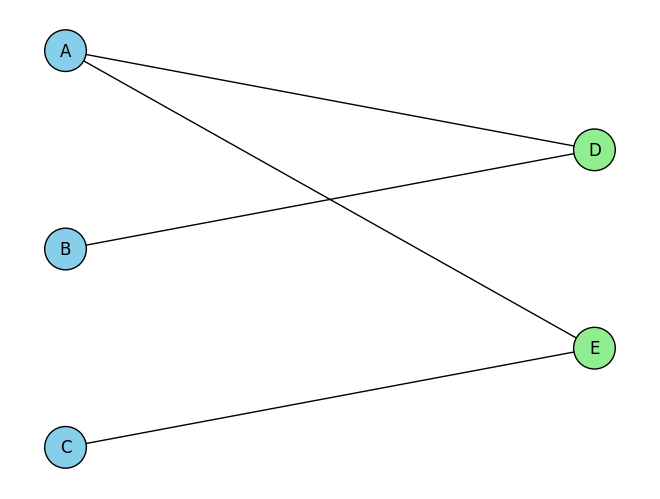

In [ ]:
from networkx.algorithms import bipartite

G = nx.Graph()

left = ["A", "B", "C"]
right = ["D", "E"]

G.add_nodes_from(left, bipartite=0)
G.add_nodes_from(right, bipartite=1)

G.add_edges_from([
    ("A","D"),
    ("A","E"),
    ("B","D"),
    ("C","E")
])

pos = {
    "A":(0,2),
    "B":(0,1),
    "C":(0,0),
    "D":(2,1.5),
    "E":(2,0.5)
}

colors = ["skyblue" if n in left else "lightgreen" for n in G.nodes()]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=colors,
    node_size=900,
    edgecolors='black',
    linewidths=1
)

plt.show()

A complete bipartite graph is denoted by $K_{m,n}$ , where every vertex in the first partition is connected to every vertex in the second partition.

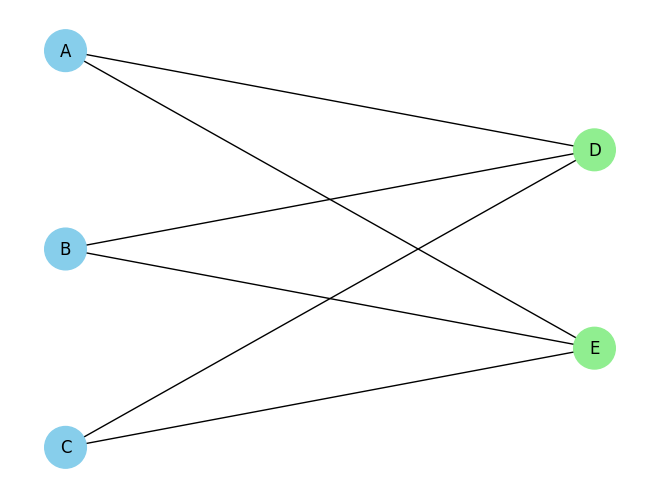

In [ ]:
G = nx.complete_bipartite_graph(3,2)

mapping = {
    0:"A",
    1:"B",
    2:"C",
    3:"D",
    4:"E"
}

G = nx.relabel_nodes(G, mapping)

left = ["A","B","C"]

pos = {
    "A":(0,2),
    "B":(0,1),
    "C":(0,0),
    "D":(2,1.5),
    "E":(2,0.5)
}

colors = ["skyblue" if n in left else "lightgreen" for n in G.nodes()]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=colors,
    node_size=900
)

plt.show()

### 4. Properties of Graphs

#### Adjacent Vertices

Two vertices **u** and **v** in an undirected graph are called **adjacent** (or **neighbors**) if there is an edge connecting them.

For example, if there is an edge between **A** and **B**, then: A is adjacent to B. B is adjacent to A.

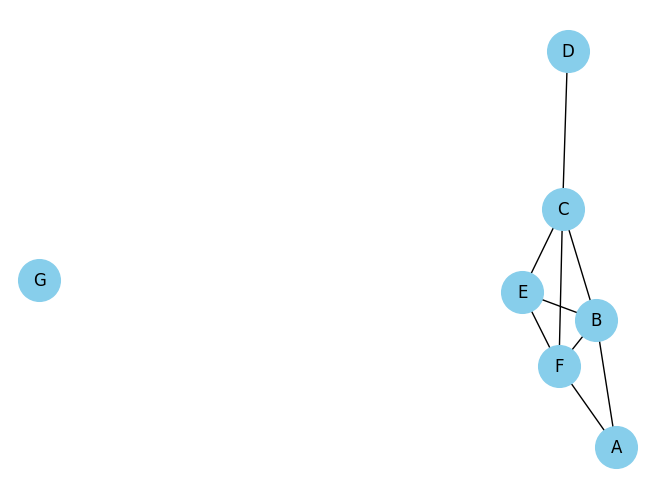

In [ ]:
G = nx.Graph()

G.add_edges_from([
    ("A","B"),
    ("A","F"),
    ("B","C"),
    ("B","E"),
    ("B","F"),
    ("C","D"),
    ("C","E"),
    ("C","F"),
    ("E","F")
])

# Isolated vertex
G.add_node("G")

pos = nx.spring_layout(G, seed=10)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=900,
    node_color="skyblue"
)

plt.show()

In [ ]:
# To check whether two vertices are adjacent:
print(G.has_edge("A", "B"))
print(G.has_edge("A", "C"))

True
False


#### Neighbors

The **neighbors** of a vertex are all vertices directly connected to that vertex.

The neighbor set of a vertex $v$ is denoted by $N(v)$

NetworkX provides the `neighbors()` function.

In [ ]:
print(list(G.neighbors("A")))

['B', 'F']


In [ ]:
# We can display the neighbors of every vertex.
for node in G.nodes():
    print(f"N({node}) =", list(G.neighbors(node)))

N(A) = ['B', 'F']
N(B) = ['A', 'C', 'E', 'F']
N(F) = ['A', 'B', 'C', 'E']
N(C) = ['B', 'D', 'E', 'F']
N(E) = ['B', 'C', 'F']
N(D) = ['C']
N(G) = []


In [ ]:
# The neighbors of a subset of vertices can also be obtained.
subset = {"A", "D"}
neighbors = set()

for node in subset:
    neighbors.update(G.neighbors(node))

neighbors -= subset
print(neighbors)

{'C', 'F', 'B'}


#### Degree of a Vertex

The **degree** of a vertex is the number of edges incident to that vertex.

The degree of vertex $v$ is denoted by $deg(v)$

Special cases:

- A vertex with degree **0** is called an **isolated vertex**.
- A vertex with degree **1** is called a **leaf vertex**.
- A self-loop contributes **2** to the degree of a vertex.

In [ ]:
for node in G.nodes():
    print(f"deg({node}) =", G.degree(node))

deg(A) = 2
deg(B) = 4
deg(F) = 4
deg(C) = 4
deg(E) = 3
deg(D) = 1
deg(G) = 0


In [ ]:
# The isolated and leaf vertices can be determined automatically.
for node in G.nodes():

    if G.degree(node) == 0:
        print(node, "is an isolated vertex")

    elif G.degree(node) == 1:
        print(node, "is a leaf vertex")

D is a leaf vertex
G is an isolated vertex


#### Degree in a Multigraph

A multigraph allows **multiple edges** and **self-loops**. Every edge contributes **1** to the degree, while a self-loop contributes **2**.

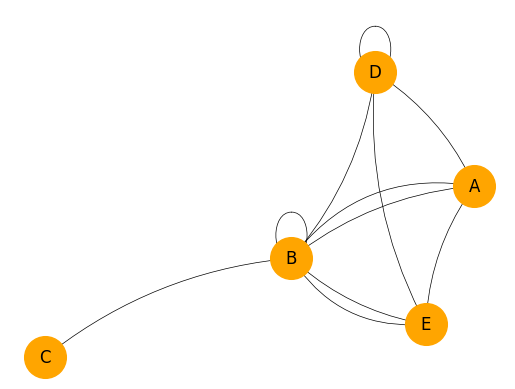

In [ ]:
MG = nx.MultiGraph()

MG.add_edges_from([
    ("A","B"),
    ("A","D"),
    ("A","E"),
    ("B","C"),
    ("B","D"),
    ("D","E")
])

# Multiple edges
MG.add_edge("A","B")
MG.add_edge("B","E")
MG.add_edge("B","E")

# Self-loops
MG.add_edge("B","B")
MG.add_edge("D","D")

# To visualize the multiple edges as curved lines:
pos = nx.spring_layout(MG, seed=15)

nx.draw_networkx_nodes(
    MG,
    pos,
    node_color="orange",
    node_size=900
)

nx.draw_networkx_labels(MG, pos)

# Draw each edge individually with curved connections
for i, edge in enumerate(MG.edges(keys=True)):
    u, v, k = edge

    if u == v:
        rad = 0.35
    else:
        rad = 0.15 * ((k % 3) + 1)

    nx.draw_networkx_edges(
        MG,
        pos,
        edgelist=[(u, v)],
        connectionstyle=f"arc3,rad={rad}",
        width=0.5
    )

plt.axis("off")
plt.show()

In [ ]:
# The degree of each vertex is computed automatically:
for node in MG.nodes():
    print(f"deg({node}) =", MG.degree(node))

deg(A) = 4
deg(B) = 8
deg(D) = 5
deg(E) = 4
deg(C) = 1


In [ ]:
# The neighbors of every vertex can also be listed:
for node in MG.nodes():
    print(f"N({node}) =", list(MG.neighbors(node)))

N(A) = ['B', 'D', 'E']
N(B) = ['A', 'C', 'D', 'E', 'B']
N(D) = ['A', 'B', 'E', 'D']
N(E) = ['A', 'D', 'B']
N(C) = ['B']


#### Handshaking Theorem

The **Handshaking Theorem** is one of the most fundamental results in graph theory. It states that in an undirected graph, every edge contributes **2** to the total degree count—one for each endpoint.

If $G=(V,E)$ is an undirected graph with $|E|$ edges, then

$$
\sum_{v \in V}\deg(v)=2|E|
$$

This theorem is useful for verifying whether the degree values of a graph are correct.

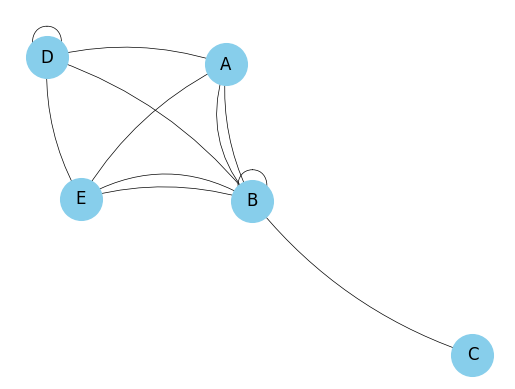

In [ ]:
G = nx.MultiGraph()

G.add_edges_from([
    ("A","B"),
    ("A","D"),
    ("A","E"),
    ("B","C"),
    ("B","D"),
    ("D","E")
])

# Multiple edges
G.add_edge("A","B")
G.add_edge("B","E")
G.add_edge("B","E")

# Self-loops
G.add_edge("B","B")
G.add_edge("D","D")

# Draw the graph with curved edges.
pos = nx.spring_layout(G, seed=20)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=900,
    node_color="skyblue"
)

nx.draw_networkx_labels(G, pos)

for u, v, k in G.edges(keys=True):

    if u == v:
        rad = 0.35
    else:
        rad = 0.15 * (k + 1)

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v)],
        connectionstyle=f"arc3,rad={rad}",
        width=0.5
    )

plt.axis("off")
plt.show()

In [ ]:
# Calculate the degree of every vertex
for node in G.nodes():
    print(f"deg({node}) = {G.degree(node)}")

deg(A) = 4
deg(B) = 8
deg(D) = 5
deg(E) = 4
deg(C) = 1


In [ ]:
# Verify the Handshaking Theorem.
total_degree = sum(dict(G.degree()).values())
num_edges = G.number_of_edges()
print("Sum of degrees:", total_degree)
print("2 × Number of edges:", 2 * num_edges)

Sum of degrees: 22
2 × Number of edges: 22


An important consequence of the Handshaking Theorem is:

> **Every undirected graph contains an even number of vertices with odd degree.**
>

We can verify this using NetworkX.

In [ ]:
odd_vertices = [
    node for node, degree in G.degree()
    if degree % 2 == 1
]

print("Odd-degree vertices:", odd_vertices)
print("Number of odd-degree vertices:", len(odd_vertices))

Odd-degree vertices: ['D', 'C']
Number of odd-degree vertices: 2


#### In-Degree and Out-Degree

For a **directed graph**, every edge has a direction. If an edge is written as $(u,v)$, then **$u$** is the **starting vertex, $v$** is the **ending vertex**.

Unlike undirected graphs, each vertex has two different degrees.

- **In-degree**  $(\deg^{-}(v))$: the number of incoming edges.
- **Out-degree** $(\deg^{+}(v))$: the number of outgoing edges.

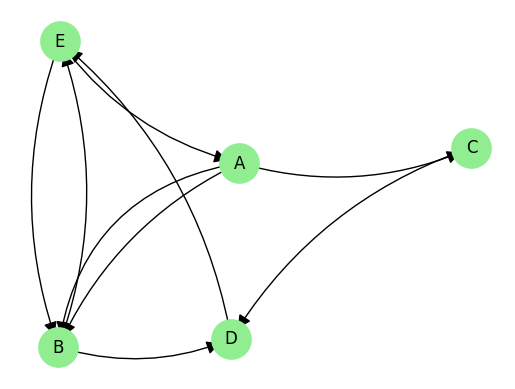

In [ ]:
DG = nx.MultiDiGraph()

DG.add_edges_from([
    ("A","B"),
    ("A","C"),
    ("B","D"),
    ("C","D"),
    ("D","E"),
    ("E","A"),
    ("B","E"),
    ("E","B"),
    ("A","B")
])

# Draw the directed graph.
pos = nx.spring_layout(DG, seed=30)

nx.draw_networkx_nodes(
    DG,
    pos,
    node_size=800, # Slightly reduced node size
    node_color="lightgreen"
)

nx.draw_networkx_labels(DG, pos)

for u, v, k in DG.edges(keys=True):
    rad = 0.18 * (k + 1)

    nx.draw_networkx_edges(
        DG,
        pos,
        edgelist=[(u, v)],
        arrows=True,
        connectionstyle=f"arc3,rad={rad}",
        arrowsize=20 # Increased arrow size
    )

plt.axis("off")
plt.show()

In [ ]:
for node in DG.nodes():
    print(
        f"{node}: "
        f"in-degree = {DG.in_degree(node)}, "
        f"out-degree = {DG.out_degree(node)}"
    )

A: in-degree = 1, out-degree = 3
B: in-degree = 3, out-degree = 2
C: in-degree = 1, out-degree = 1
D: in-degree = 2, out-degree = 1
E: in-degree = 2, out-degree = 2


**Degree Property of Directed Graphs**

For every directed graph:

$$
\sum_{v\in V}\deg^{-}(v) + \sum_{v\in V}\deg^{+}(v) = |E|
$$

Each directed edge contributes: **1** to the out-degree of its starting vertex; **1** to the in-degree of its ending vertex.

Therefore, the total in-degree always equals the total out-degree, and both equal the total number of edges.

In [ ]:
total_in = sum(dict(DG.in_degree()).values())
total_out = sum(dict(DG.out_degree()).values())

print("Total in-degree :", total_in)
print("Total out-degree:", total_out)
print("Number of edges :", DG.number_of_edges())

Total in-degree : 9
Total out-degree: 9
Number of edges : 9


### 5. Forming New Graphs from Existing Graphs

#### Subgraph

A **subgraph** of a graph $G=(V,E)$ is another graph $H=(W,F)$ where $W \subseteq V$ and $F \subseteq E$

A **proper (true) subgraph** is a subgraph that is not identical to the original graph.

A common type of subgraph is the **subgraph induced by a vertex set** $W$. It contains all vertices in $W$ and every edge from the original graph whose two endpoints are both in $W$.

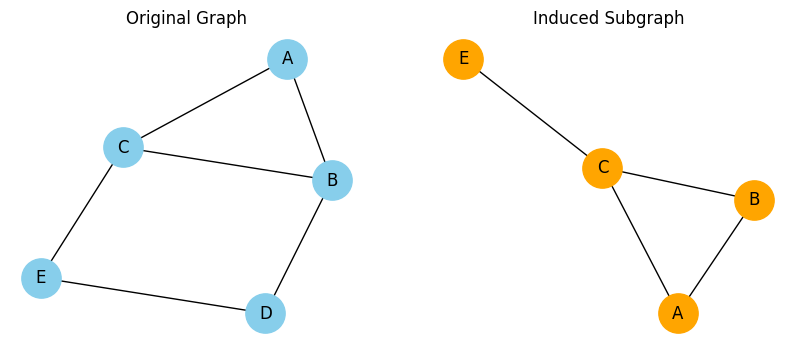

In [ ]:
# Original graph
G = nx.Graph()

G.add_edges_from([
    ("A","B"),
    ("A","C"),
    ("B","C"),
    ("B","D"),
    ("C","E"),
    ("D","E")
])

# Induced subgraph
H = G.subgraph(["A","B","C","E"])

plt.figure(figsize=(10,4))

plt.subplot(121)
nx.draw(G,
        with_labels=True,
        node_color="skyblue",
        node_size=800)

plt.title("Original Graph")

plt.subplot(122)
nx.draw(H,
        with_labels=True,
        node_color="orange",
        node_size=800)

plt.title("Induced Subgraph")

plt.show()

#### Removing Edges

A new graph can be created by removing one or more edges while keeping the same set of vertices.

For removing one edge $e$, $G-e=(V,E-{e})$. If multiple edges are removed, $G-E'=(V,E-E')$  where $(E' \subseteq E)$.

In the following example, we will create a complete graph and then remove three edges at random.

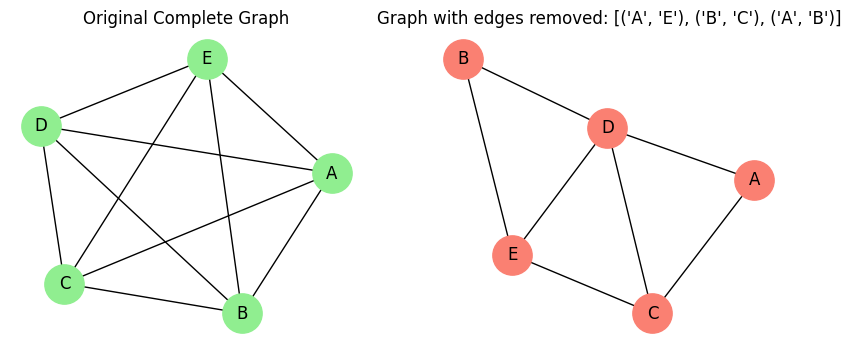

In [ ]:
import random

G = nx.complete_graph(5)

mapping = {0:"A",1:"B",2:"C",3:"D",4:"E"}
G = nx.relabel_nodes(G, mapping)

G_removed = G.copy()

# Get all edges as a list
all_edges = list(G_removed.edges())

# Select 3 random edges to remove
# Ensure there are at least 3 edges to remove
if len(all_edges) >= 3:
    edges_to_remove = random.sample(all_edges, 3)
    # Remove the selected edges
    G_removed.remove_edges_from(edges_to_remove)
else:
    edges_to_remove = []
    print("Not enough edges to remove 3.")

plt.figure(figsize=(10,4))

plt.subplot(121)
nx.draw(G,
        with_labels=True,
        node_color="lightgreen",
        node_size=800)

plt.title("Original Complete Graph")

plt.subplot(122)
nx.draw(G_removed,
        with_labels=True,
        node_color="salmon",
        node_size=800)

plt.title(f"Graph with edges removed: {edges_to_remove}")

plt.show()

#### Adding Edges

We can also create a new graph by adding edges between existing vertices.

If $e$ is a new edge, $G+e=(V,E\cup{e})$. Only the edge set changes, while the vertex set remains the same.

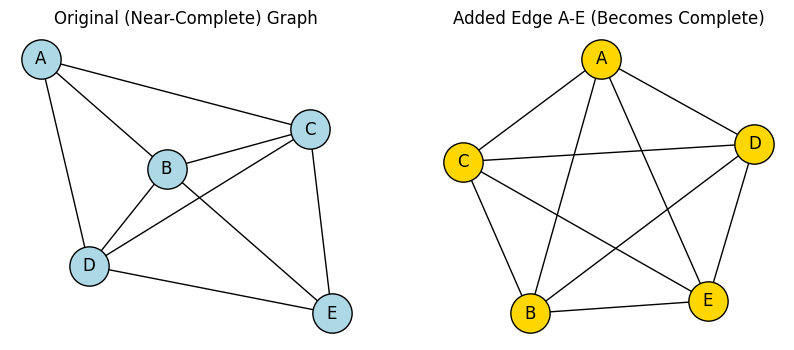

In [ ]:
# Create a complete graph and make it 'near-complete' by removing an edge
G = nx.complete_graph(5)
mapping = {0:"A", 1:"B", 2:"C", 3:"D", 4:"E"}
G = nx.relabel_nodes(G, mapping)

# Remove an edge to make it near-complete
G.remove_edge("A", "E")

G_added = G.copy()
# Add the missing edge back
G_added.add_edge("A", "E")

plt.figure(figsize=(10, 4))

plt.subplot(121)
nx.draw(G,
        with_labels=True,
        node_color="lightblue",
        node_size=800,
        edgecolors='black')
plt.title("Original (Near-Complete) Graph")

plt.subplot(122)
nx.draw(G_added,
        with_labels=True,
        node_color="gold",
        node_size=800,
        edgecolors='black')
plt.title("Added Edge A-E (Becomes Complete)")

plt.show()

#### Edge Reduction (Edge Contraction)

Edge reduction (also called **edge contraction**) removes an edge and merges its two connected vertices into a single new vertex. The new vertex inherits all connections that previously belonged to either of the merged vertices.

This operation is useful for simplifying graphs while preserving their overall connectivity.

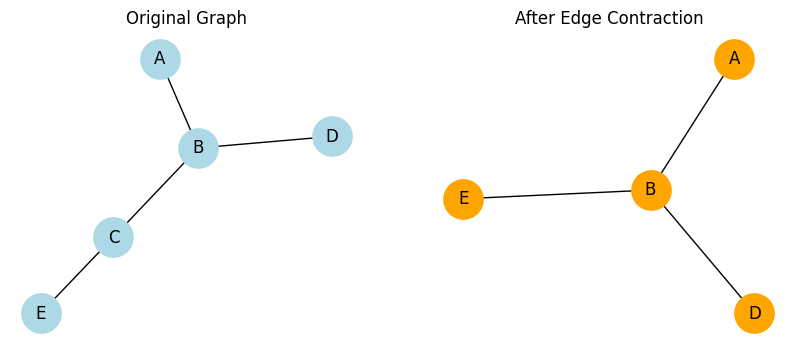

In [ ]:
# Original graph
G = nx.Graph()

G.add_edges_from([
    ("A","B"),
    ("B","C"),
    ("B","D"),
    ("C","E")
])

# Contract edge (B,C)
H = nx.contracted_nodes(G, "B", "C", self_loops=False)

plt.figure(figsize=(10,4))

plt.subplot(121)
nx.draw(G,
        with_labels=True,
        node_color="lightblue",
        node_size=800)

plt.title("Original Graph")

plt.subplot(122)
nx.draw(H,
        with_labels=True,
        node_color="orange",
        node_size=800)

plt.title("After Edge Contraction")

plt.show()

#### Removing Vertices

A graph can also be modified by removing a vertex together with every edge connected to it.

If vertex $v$ is removed, $G-v$ contains all remaining vertices and all edges not incident to $v$

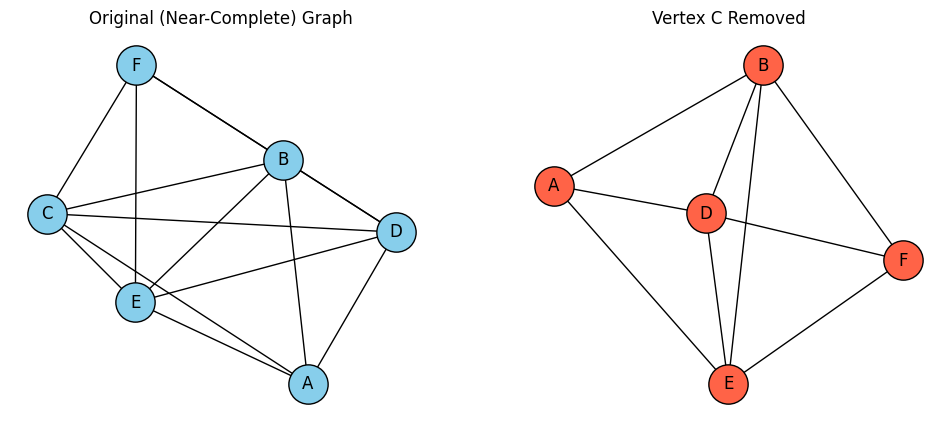

In [ ]:
# Create a complete graph with 6 nodes
G = nx.complete_graph(6)
mapping = {0:"A", 1:"B", 2:"C", 3:"D", 4:"E", 5:"F"}
G = nx.relabel_nodes(G, mapping)

# Make it 'near-complete' by removing one edge
G.remove_edge("A", "F")

# Create a copy and remove vertex C
H = G.copy()
H.remove_node("C")

plt.figure(figsize=(12, 5))

plt.subplot(121)
nx.draw(G,
        with_labels=True,
        node_color="skyblue",
        node_size=800,
        edgecolors='black')
plt.title("Original (Near-Complete) Graph")

plt.subplot(122)
nx.draw(H,
        with_labels=True,
        node_color="tomato",
        node_size=800,
        edgecolors='black')
plt.title("Vertex C Removed")

plt.show()

#### Union of Graphs

The **union** of two graphs combines all vertices and all edges from both graphs.

For $G_1=(V_1,E_1)$ and $G_2=(V_2,E_2)$ their union is $G_1\cup G_2=(V_1\cup V_2,;E_1\cup E_2)$

The resulting graph contains every vertex and every edge that appears in either graph.

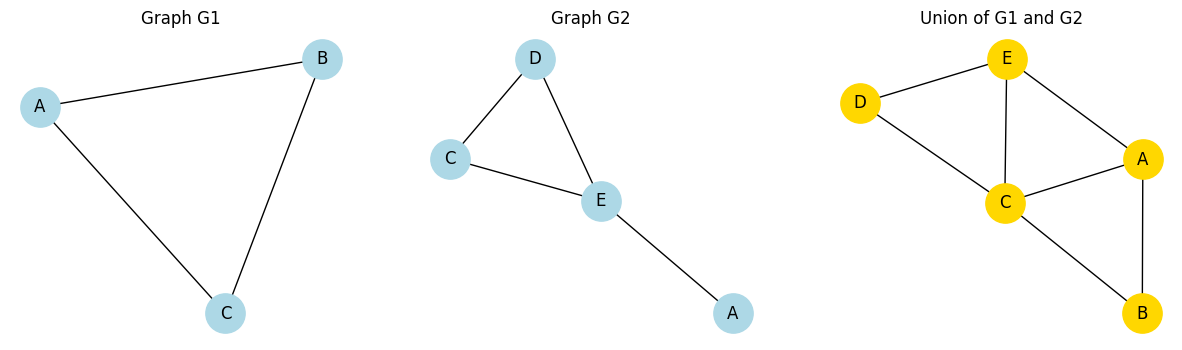

In [ ]:
G1 = nx.Graph()
G1.add_edges_from([
    ("A","B"),
    ("B","C"),
    ("A","C")
])

G2 = nx.Graph()
G2.add_edges_from([
    ("C","D"),
    ("D","E"),
    ("A","E"),
    ("C","E")
])

# Union
G_union = nx.compose(G1, G2)

plt.figure(figsize=(15,4))

plt.subplot(131)
nx.draw(G1,
        with_labels=True,
        node_color="lightblue",
        node_size=800)

plt.title("Graph G1")

plt.subplot(132)
nx.draw(G2,
        with_labels=True,
        node_color="lightblue",
        node_size=800)

plt.title("Graph G2")

plt.subplot(133)
nx.draw(G_union,
        with_labels=True,
        node_color="gold",
        node_size=800)

plt.title("Union of G1 and G2")

plt.show()

### 6. Weighted Graphs and Representing Graphs

#### Weighted Graph

A **weighted graph** is a graph in which every edge is assigned a numerical value called a **weight** (or **cost**).

Unlike an unweighted graph, where every edge is considered equal, weighted graphs allow algorithms to determine optimal paths, minimum costs, and shortest routes.

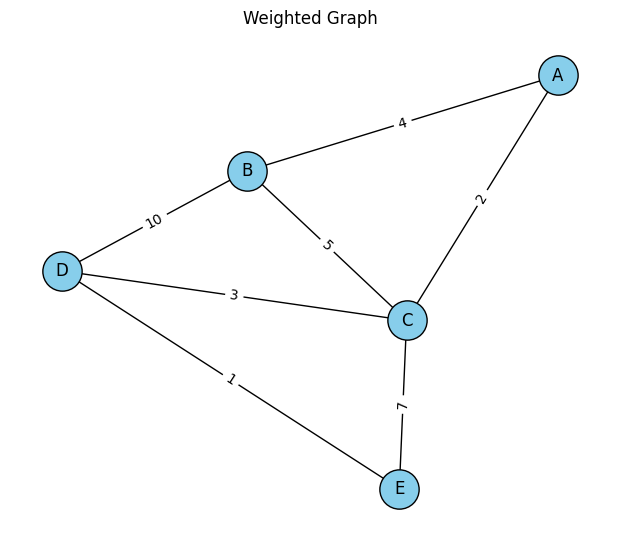

In [ ]:
G = nx.Graph()

G.add_weighted_edges_from([
    ("A", "B", 4),
    ("A", "C", 2),
    ("B", "C", 5),
    ("B", "D", 10),
    ("C", "D", 3),
    ("C", "E", 7),
    ("D", "E", 1)
])

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(6,5))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="skyblue",
    node_size=800,
    edgecolors='black'
)

edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Weighted Graph")
plt.show()

#### Converting a Graph into a Adjacency Matrix

An adjacency matrix records whether pairs of vertices are connected.

Suppose $G=(V,E)$ contains $ |V|=n$ vertices $v_1,v_2,\ldots,v_n$. The adjacency matrix is an $n\times n$ matrix $A=[a_{ij}]$ where $a_{ij}= \begin{cases} 1,&\text{if }(v_i,v_j)\in E\\ 0,&\text{otherwise} \end{cases}$

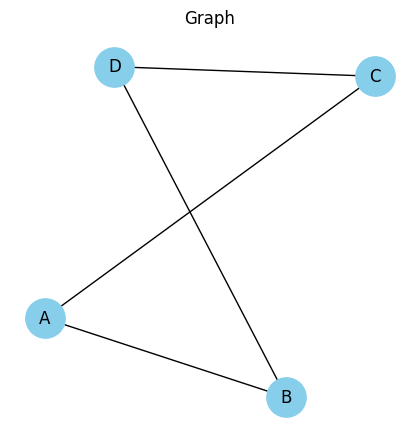

In [ ]:
G = nx.Graph()

G.add_edges_from([
    ("A","B"),
    ("A","C"),
    ("B","D"),
    ("C","D")
])

plt.figure(figsize=(4,4))
nx.draw(
    G,
    with_labels=True,
    node_color="skyblue",
    node_size=800
)
plt.title("Graph")
plt.show()

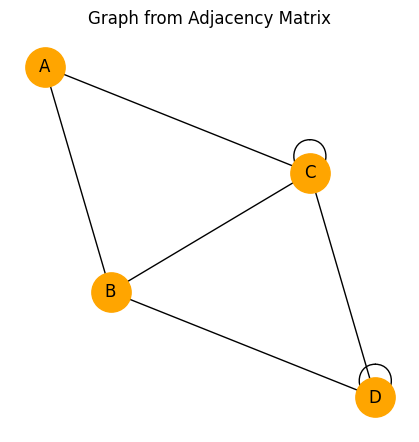

In [ ]:
# NetworkX can also reconstruct a graph directly from an adjacency matrix.
import pandas as pd


A = pd.DataFrame(
    [
        [0,0,1,0],
        [1,0,1,1],
        [1,1,1,1],
        [0,1,0,1]
    ],
    index=["A","B","C","D"],
    columns=["A","B","C","D"]
)

G = nx.from_pandas_adjacency(A)

plt.figure(figsize=(4,4))

nx.draw(
    G,
    with_labels=True,
    node_color="orange",
    node_size=800
)

plt.title("Graph from Adjacency Matrix")
plt.show()

**Properties of an Adjacency Matrix**

- **Undirected Graphs**: For an undirected graph, $a_{ij}=a_{ji}$. Therefore, the adjacency matrix is **symmetric**. For simple graphs, $a_{ii}=0$ because no vertex has an edge connecting to itself.

- **Directed Graphs:** For directed graphs, $a_{ij}\neq a_{ji}$ in general. The adjacency matrix is therefore **not necessarily symmetric**.

   A  B  C  D
A  0  1  0  1
B  0  0  1  0
C  1  0  0  0
D  0  0  0  0


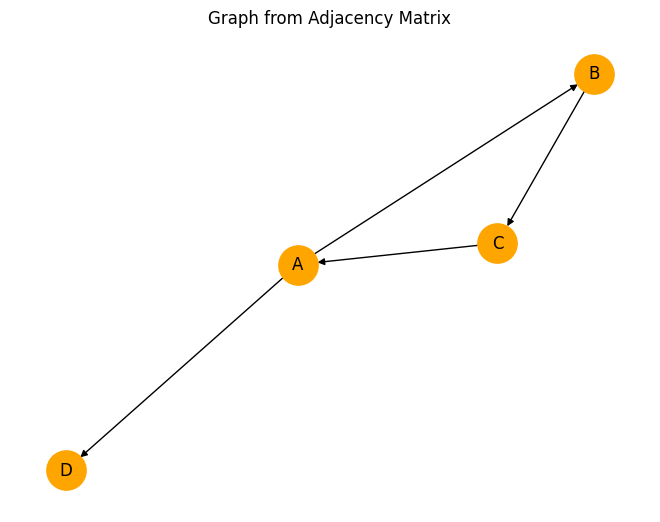

In [ ]:
import pandas as pd

G = nx.DiGraph()

G.add_edges_from([
    ("A","B"),
    ("B","C"),
    ("C","A"),
    ("A","D")
])

A = nx.to_pandas_adjacency(
    G,
    dtype=int
)

print(A)

nx.draw(
    G,
    with_labels=True,
    node_color="orange",
    node_size=800,
    arrows=True
)

plt.title("Graph from Adjacency Matrix")
plt.show()

#### Weighted Adjacency Matrix

When values in the adjacency matrix are greater than 1, it is no longer a simple adjacency matrix. Instead, it becomes a **weighted adjacency matrix** where each value represents the weight (strength, distance, or capacity) of the connection between two vertices.

To visualize these, we can extract the 'weight' attribute from the edges and display them as labels.

     A    B    C    D    E
A  0.0  4.0  2.0  0.0  0.0
B  4.0  0.0  5.0  1.0  0.0
C  2.0  5.0  0.0  3.0  7.0
D  0.0  1.0  3.0  0.0  1.0
E  0.0  0.0  7.0  1.0  0.0


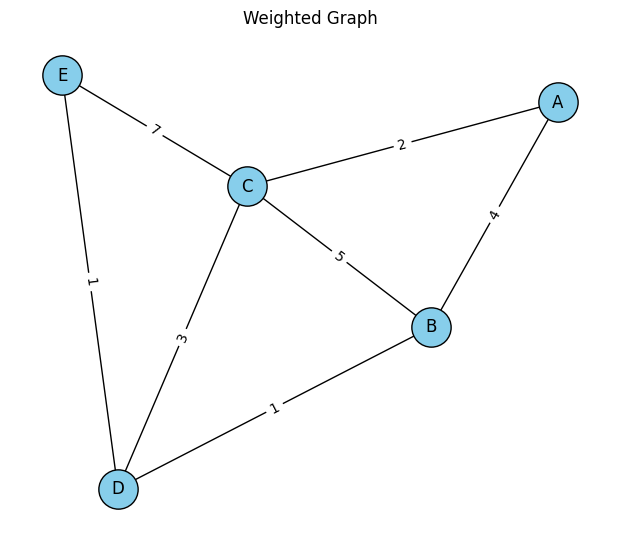

In [ ]:
G = nx.Graph()

G.add_weighted_edges_from([
    ("A", "B", 4),
    ("A", "C", 2),
    ("B", "C", 5),
    ("B", "D", 1),
    ("C", "D", 3),
    ("C", "E", 7),
    ("D", "E", 1)
])

nodes = sorted(G.nodes())

A = nx.to_pandas_adjacency(
    G,
    nodelist=nodes,
    weight="weight"
)

print(A)

# Visualize the graph
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(6,5))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="skyblue",
    node_size=800,
    edgecolors='black'
)

edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Weighted Graph")
plt.show()

#### Converting a Graph into a Incidence Matrix

An **incidence matrix** describes the relationship between **vertices** and **edges**.

Suppose $n$ vertices and $m$ edges. The incidence matrix has dimensions $n\times m$.  Each **row** represents a vertex, while each **column** represents an edge.

For an undirected graph:

$$
m_{ij}= \begin{cases} 1,&\text{if edge }e_j\text{ is incident to }v_i\\ 0,&\text{otherwise} \end{cases}
$$

Since every edge connects exactly two vertices, each column contains exactly two entries equal to 1.

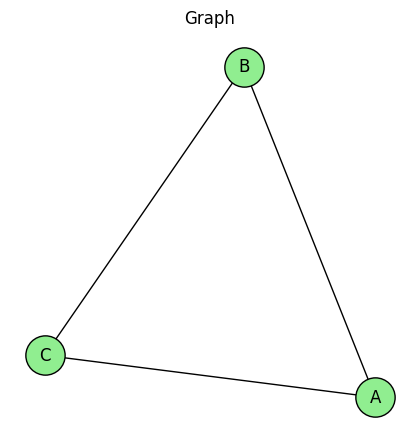

In [ ]:
G = nx.Graph()

G.add_edges_from([
    ("A","B"),
    ("A","C"),
    ("B","C")
])

plt.figure(figsize=(4,4))
nx.draw(
    G,
    with_labels=True,
    node_color="lightgreen",
    node_size=800,
    edgecolors='black'
)
plt.title("Graph")
plt.show()

In [ ]:
# Generate the incidence matrix.
nodes = sorted(G.nodes())
edges = list(G.edges())

M = nx.incidence_matrix(
    G,
    nodelist=nodes,
    edgelist=edges,
    oriented=False
).todense()

columns = [f"e{i+1}" for i in range(len(edges))]

df = pd.DataFrame(
    M,
    index=nodes,
    columns=columns
)

print(df)

    e1   e2   e3
A  1.0  1.0  0.0
B  1.0  0.0  1.0
C  0.0  1.0  1.0


**Directed Graph Incidence Matrix**

For directed graphs, we often call it an **oriented incidence matrix**.

- **−1** indicates the edge leaves the vertex.
- **+1** indicates the edge enters the vertex.

    e1   e2   e3
A -1.0 -1.0  0.0
B  1.0  0.0  1.0
C  0.0  1.0 -1.0


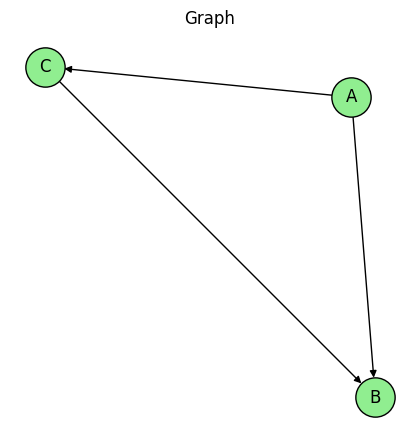

In [ ]:
G = nx.DiGraph()

G.add_edges_from([
    ("A","B"),
    ("A","C"),
    ("C","B")
])

nodes = sorted(G.nodes())
edges = list(G.edges())

M = nx.incidence_matrix(
    G,
    nodelist=nodes,
    edgelist=edges,
    oriented=True
).todense()

columns = [f"e{i+1}" for i in range(len(edges))]

df = pd.DataFrame(
    M,
    index=nodes,
    columns=columns
)

print(df)

plt.figure(figsize=(4,4))
nx.draw(
    G,
    with_labels=True,
    node_color="lightgreen",
    node_size=800,
    edgecolors='black'
)
plt.title("Graph")
plt.show()

**Incidence Matrix for Multigraphs**

The incidence matrix can also represent multigraphs.

- Multiple edges are represented by separate columns.
- Self-loops are represented by a column corresponding to the vertex containing the loop.

    e1   e2   e3   e4   e5   e6
A  1.0  1.0  1.0  0.0  0.0  0.0
B  1.0  1.0  0.0  1.0  1.0  0.0
C  0.0  0.0  0.0  1.0  0.0  0.0
D  0.0  0.0  1.0  0.0  1.0  0.0


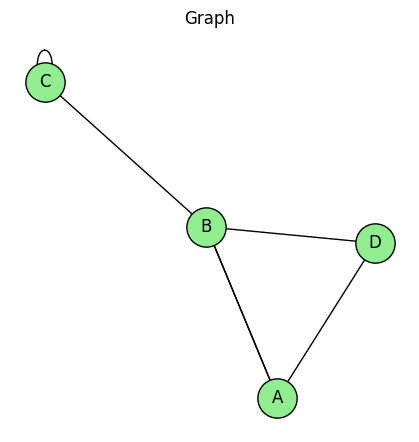

In [ ]:
G = nx.MultiGraph()

G.add_edge("A", "B")
G.add_edge("A", "B")   # Multiple edge
G.add_edge("B", "C")
G.add_edge("C", "C")   # Self-loop
G.add_edge("A", "D")
G.add_edge("B", "D")

nodes = sorted(G.nodes())
edges = list(G.edges(keys=True))

M = nx.incidence_matrix(
    G,
    nodelist=nodes,
    edgelist=edges,
    oriented=False
).todense()

columns = [f"e{i+1}" for i in range(len(edges))]

df = pd.DataFrame(
    M,
    index=nodes,
    columns=columns
)

print(df)

plt.figure(figsize=(4,4))
nx.draw(
    G,
    with_labels=True,
    node_color="lightgreen",
    node_size=800,
    edgecolors='black'
)
plt.title("Graph")
plt.show()

### 7. Graph Homomorphism

Two graphs are **homomorphic (isomorphic)** if one graph can be transformed into the other simply by renaming its vertices without changing the connections between them.

Formally, let $G=(V_1,E_1)$ and $H=(V_2,E_2)$ be two simple graphs.

The graphs are homomorphic if there exists a **bijection** $f:V_1\rightarrow V_2$ such that for every pair of vertices $(a,b\in V_1)$, $(a,b)\in E_1 \ \Longleftrightarrow\ (f(a),f(b))\in E_2.$

In other words, two vertices are adjacent in $G$ if and only if their corresponding vertices are adjacent in $H$. Such a mapping $f$  is called a **graph homomorphism**.

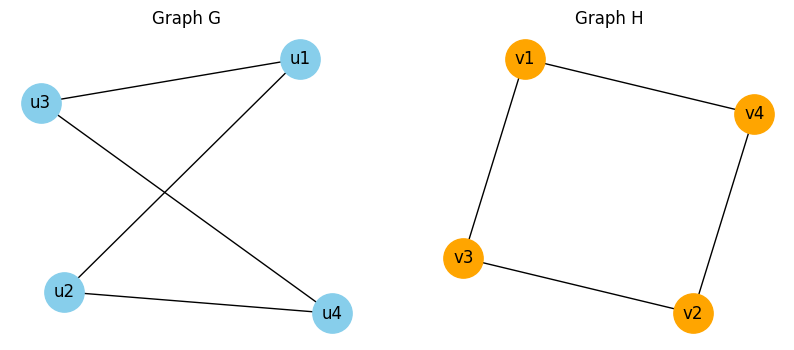

The two graphs are homomorphobic.


In [ ]:
# Example 1: Two Homomorphic (Isomorphic) Graphs
# Although the vertex labels are different,
# both graphs have the same structure.

# Graph G
G = nx.Graph()

G.add_edges_from([
    ("u1", "u2"),
    ("u1", "u3"),
    ("u2", "u4"),
    ("u3", "u4")
])

# Graph H
H = nx.Graph()

H.add_edges_from([
    ("v1", "v4"),
    ("v1", "v3"),
    ("v4", "v2"),
    ("v3", "v2")
])

plt.figure(figsize=(10,4))

plt.subplot(121)
nx.draw(
    G,
    with_labels=True,
    node_color="skyblue",
    node_size=800
)
plt.title("Graph G")

plt.subplot(122)
nx.draw(
    H,
    with_labels=True,
    node_color="orange",
    node_size=800
)
plt.title("Graph H")

plt.show()

# Determint if the two graphs are homomorphobic
if nx.is_isomorphic(G, H):
    print("The two graphs are homomorphobic.")
else:
    print("The two graphs are not homomorphobic.")

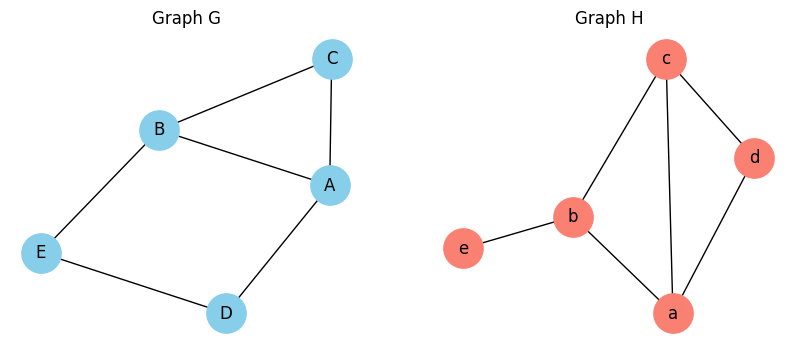

Degrees of G
{'A': 3, 'B': 3, 'C': 2, 'D': 2, 'E': 2}

Degrees of H
{'a': 3, 'b': 3, 'c': 3, 'd': 2, 'e': 1}
The two graphs are not homomorphobic.


In [ ]:
# Example 2: Not Homomorphic (Different Degree Sequence)
# Graph H contains one vertex of degree 1, while G has no vertex with degree 1.

# Graph G
G = nx.Graph()

G.add_edges_from([
    ("A","B"),
    ("A","C"),
    ("A","D"),
    ("B","C"),
    ("B","E"),
    ("D","E")
])

# Graph H
H = nx.Graph()

H.add_edges_from([
    ("a","b"),
    ("a","c"),
    ("a","d"),
    ("b","c"),
    ("b","e"),
    ("c","d")
])

plt.figure(figsize=(10,4))

plt.subplot(121)
nx.draw(
    G,
    with_labels=True,
    node_color="skyblue",
    node_size=800
)
plt.title("Graph G")

plt.subplot(122)
nx.draw(
    H,
    with_labels=True,
    node_color="salmon",
    node_size=800
)
plt.title("Graph H")

plt.show()

print("Degrees of G")
print(dict(G.degree()))

print("\nDegrees of H")
print(dict(H.degree()))

# Determint if the two graphs are homomorphobic
if nx.is_isomorphic(G, H):
    print("The two graphs are homomorphobic.")
else:
    print("The two graphs are not homomorphobic.")

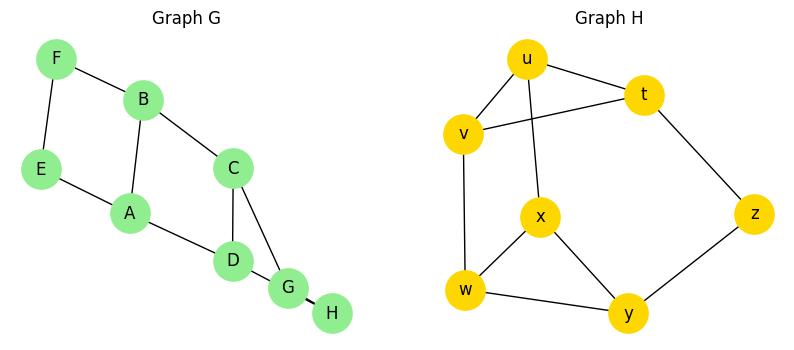

Degree sequence of G:
[2, 2, 2, 2, 3, 3, 3, 3]

Degree sequence of H:
[2, 3, 3, 3, 3, 3, 3]
The two graphs are not homomorphobic.


In [ ]:
# Example 3: Same Degree Sequence but Not Homomorphic
# Both graphs have: 8 vertices; 10 edges; Four vertices of degree 2;  \Four vertices of degree 3
# However, their connectivity is different.

# Graph G
G = nx.Graph()

G.add_edges_from([
    ("A","B"),
    ("B","C"),
    ("C","D"),
    ("D","A"),
    ("A","E"),
    ("B","F"),
    ("C","G"),
    ("D","H"),
    ("E","F"),
    ("G","H")
])

# Graph H
H = nx.Graph()

H.add_edges_from([
    ("t","u"),
    ("u","v"),
    ("v","w"),
    ("w","x"),
    ("x","y"),
    ("y","z"),
    ("z","t"),
    ("t","v"),
    ("w","y"),
    ("u","x")
])

plt.figure(figsize=(10,4))

plt.subplot(121)
nx.draw(
    G,
    with_labels=True,
    node_color="lightgreen",
    node_size=800
)
plt.title("Graph G")

plt.subplot(122)
nx.draw(
    H,
    with_labels=True,
    node_color="gold",
    node_size=800
)
plt.title("Graph H")

plt.show()

print("Degree sequence of G:")
print(sorted([d for _, d in G.degree()]))

print("\nDegree sequence of H:")
print(sorted([d for _, d in H.degree()]))

# Determint if the two graphs are homomorphobic
if nx.is_isomorphic(G, H):
    print("The two graphs are homomorphobic.")
else:
    print("The two graphs are not homomorphobic.")

### 8. Path and Connectivity in Graph

#### Paths in an Undirected Graph

Let $G=(V,E)$ be an **undirected graph**, and let $n$ be a non-negative integer.

A **path of length $n$** from vertex $u$ to vertex $v$ is a sequence of $n$ edges $e_1,e_2,\ldots,e_n$ such that there exists a sequence of vertices $x_0=u,x_1,x_2,\ldots,x_n=v$ where each edge $e_i$ connects the vertices $x_{i-1}\text{ and }x_i,\ i=1,2,\ldots,n$.

For a **simple graph**, a path is usually written simply as the sequence of vertices because each consecutive pair uniquely determines the edge.

- **Path Length:** The **length of a path** is the number of edges it contains.

- **Cycle:** A cycle is a path that begins and ends at the same vertex and has length greater than zero.

- **Simple Path**: A simple (singular) path is a path that does not traverse the same edge more than once. For simple graphs, this usually also means that vertices are not revisited (except when forming a cycle).

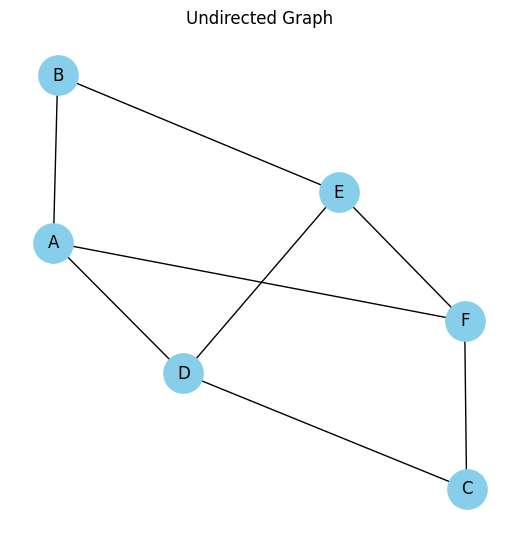

In [ ]:
G = nx.Graph()

G.add_edges_from([
    ("A","B"),
    ("A","D"),
    ("A","F"),
    ("B","E"),
    ("C","D"),
    ("C","F"),
    ("D","E"),
    ("E","F")
])

plt.figure(figsize=(5,5))

nx.draw(
    G,
    with_labels=True,
    node_color="skyblue",
    node_size=800
)

plt.title("Undirected Graph")
plt.show()

In [ ]:
# Checking a Path

path1 = ["A","D","C","F","E"]

is_path = all(
    G.has_edge(path1[i], path1[i+1])
    for i in range(len(path1)-1)
)

print("Is path?", is_path)
print("Length =", len(path1)-1)

path2 = ["D","E","C","A","F"]

is_path = all(
    G.has_edge(path2[i], path2[i+1])
    for i in range(len(path2)-1)
)

print("\nIs path?", is_path)
print("Length =", len(path2)-1)

path3 = ["A","B","E","D","A", "B"]

is_path = all(
    G.has_edge(path3[i], path3[i+1])
    for i in range(len(path3)-1)
)

print("\nIs path?", is_path)
print("Length =", len(path3)-1)

Is path? True
Length = 4

Is path? False
Length = 4

Is path? True
Length = 5


#### Paths in a Directed Graph

Let $G=(V,E)$ be a **directed graph**. A directed path is similar to a path in an undirected graph, except that **every edge must be followed in its direction**.

A path from $u$ to $v$ is a sequence $x_0=u,x_1,\ldots,x_n=v$ such that every directed edge $(x_{i-1},x_i)$ exists in the graph.

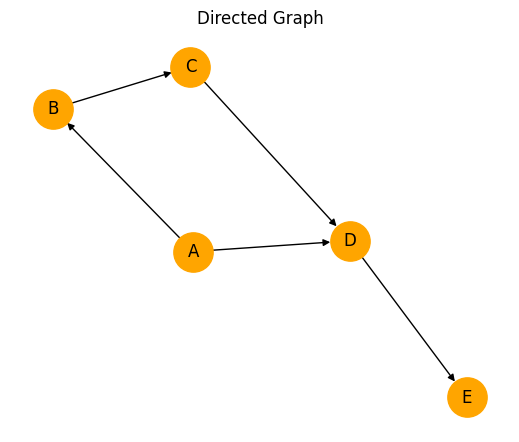

In [ ]:
G = nx.DiGraph()

G.add_edges_from([
    ("A","B"),
    ("B","C"),
    ("C","D"),
    ("A","D"),
    ("D","E")
])

plt.figure(figsize=(5,4))

nx.draw(
    G,
    with_labels=True,
    node_color="orange",
    node_size=800,
    arrows=True
)

plt.title("Directed Graph")
plt.show()

In [ ]:
# NetworkX can automatically determine whether a path exists
# and return one such path.
path = nx.shortest_path(G, "A", "E")

print("Path:", path)
print("Length:", len(path)-1)

Path: ['A', 'D', 'E']
Length: 2


### 9. Walks, Trails, Cycles, and Circuits in Graphs

#### Walk

A **walk** is the most general way of traversing a graph. It is a sequence of vertices where every consecutive pair of vertices is connected by an edge.

Unlike a path, vertices **may be repeated**, edges **may also be repeated**. Therefore, every path is a walk, but not every walk is a path.

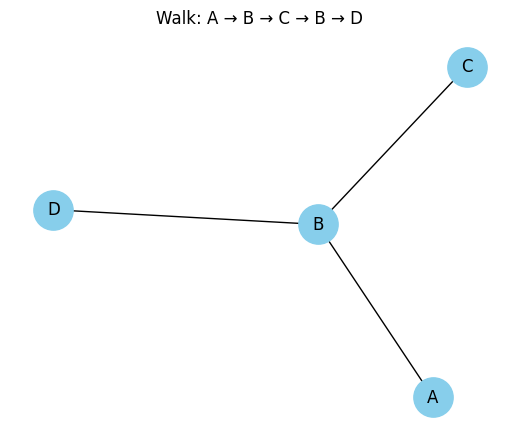

Walk: ['A', 'B', 'C', 'B', 'D']


In [ ]:
G = nx.Graph()

G.add_edges_from([
    ("A","B"),
    ("B","C"),
    ("B","D")
])

walk = ["A","B","C","B","D"]

plt.figure(figsize=(5,4))

nx.draw(
    G,
    with_labels=True,
    node_color="skyblue",
    node_size=800
)

plt.title("Walk: A → B → C → B → D")
plt.show()

print("Walk:", walk)

#### Trail

A **trail** is a walk in which **no edge is used more than once**. Vertices may still be visited multiple times, provided that a different edge is used each time.

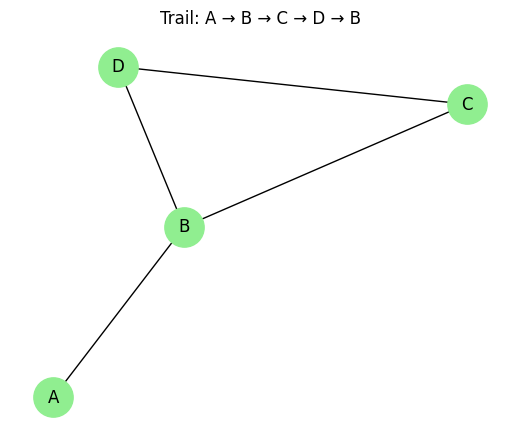

Trail: ['A', 'B', 'C', 'D', 'B']


In [ ]:
G = nx.Graph()

G.add_edges_from([
    ("A","B"),
    ("B","C"),
    ("C","D"),
    ("D","B")
])

trail = ["A","B","C","D","B"]

plt.figure(figsize=(5,4))

nx.draw(
    G,
    with_labels=True,
    node_color="lightgreen",
    node_size=800
)

plt.title("Trail: A → B → C → D → B")
plt.show()

print("Trail:", trail)

#### Cycle

A **cycle** is a path that starts and ends at the same vertex, has at least one edge, and does not repeat any vertex except the first and last.

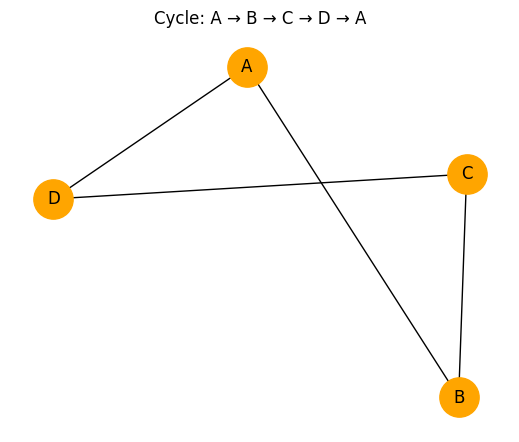

Cycle: ['A', 'B', 'C', 'D', 'A']


In [ ]:
G = nx.Graph()

G.add_edges_from([
    ("A","B"),
    ("B","C"),
    ("C","D"),
    ("D","A")
])

cycle = ["A","B","C","D","A"]

plt.figure(figsize=(5,4))

nx.draw(
    G,
    with_labels=True,
    node_color="orange",
    node_size=800
)

plt.title("Cycle: A → B → C → D → A")
plt.show()

print("Cycle:", cycle)

#### Circuit

A **circuit** is a **closed trail**, meaning that it starts and ends at the same vertex, **no edge is repeated**, and vertices may be repeated.

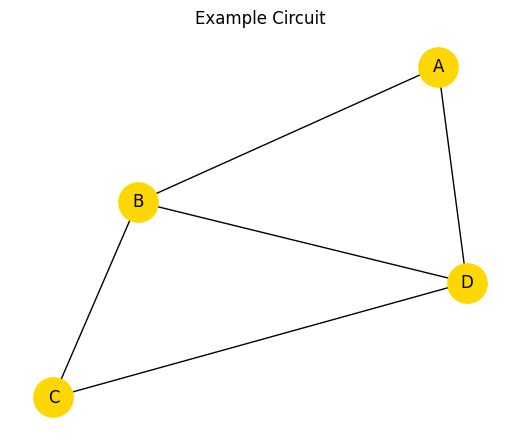

Circuit: ['A', 'B', 'C', 'D', 'A']


In [ ]:
G = nx.Graph()

G.add_edges_from([
    ("A","B"),
    ("B","C"),
    ("C","D"),
    ("D","B"),
    ("A","D")
])

circuit = ["A","B","C","D","A"]

plt.figure(figsize=(5,4))

nx.draw(
    G,
    with_labels=True,
    node_color="gold",
    node_size=800
)

plt.title("Example Circuit")
plt.show()

print("Circuit:", circuit)

### 10. Euler Paths and Circuits

#### Euler Circuit

An **Euler Circuit** (or Euler Cycle) is a path that sarts and ends at the same vertex and visits **every edge exactly once**.

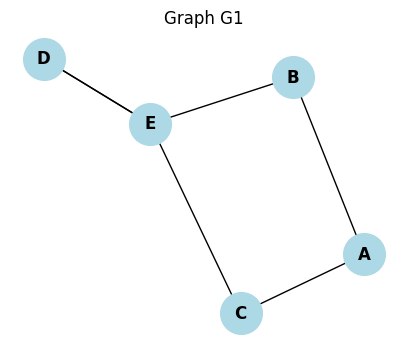

Euler Circuit: [('A', 'C'), ('C', 'E'), ('E', 'D'), ('D', 'E'), ('E', 'B'), ('B', 'A')]


In [ ]:
G1 = nx.MultiGraph()

edges = [
    ("A","B"),
    ("A","C"),
    ("B","E"),
    ("C","E"),
    ("D","E"),
    ("D","E")
]

G1.add_edges_from(edges)

plt.figure(figsize=(5,4))
pos = nx.spring_layout(G1, seed=8)

nx.draw_networkx(
    G1,
    pos,
    node_color="lightblue",
    node_size=900,
    font_weight="bold"
)

plt.title("Graph G1")
plt.axis("off")
plt.show()

print("Euler Circuit:", list(nx.eulerian_circuit(G1)))

#### Euler Path

An **Euler Path** (or Euler Trail) is a path that visits every edge exactly once and **does** **not** have to end at the starting vertex.

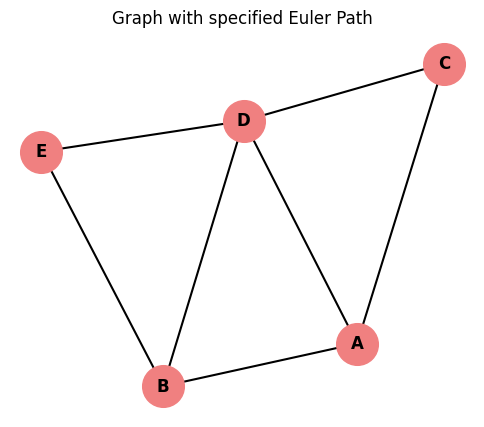

Has Euler Path : True
Is Euler Circuit : False

Euler Path:
[('A', 'C'), ('C', 'D'), ('D', 'A'), ('A', 'B'), ('B', 'D'), ('D', 'E'), ('E', 'B')]


In [ ]:
G = nx.MultiGraph()

edges = [
    ("A", "C"),
    ("C", "D"),
    ("D", "E"),
    ("E", "B"),
    ("B", "D"),
    ("D", "A"),
    ("A", "B")
]

G.add_edges_from(edges)

plt.figure(figsize=(6, 5))
pos = nx.spring_layout(G, seed=10)  # Use a fixed seed for consistent layout

nx.draw_networkx_nodes(
    G,
    pos,
    node_color="lightcoral",
    node_size=900
)

nx.draw_networkx_labels(G, pos, font_size=12, font_weight="bold") # Moved font_weight to labels

# Draw edges with curvature to distinguish multiple edges
edge_offsets = {}
for u, v, key in G.edges(keys=True):
    node_pair = tuple(sorted((u, v)))

    if node_pair not in edge_offsets:
        edge_offsets[node_pair] = 0
    else:
        edge_offsets[node_pair] += 1

    rad_magnitude = 0.1 * ((edge_offsets[node_pair] // 2) + 1)
    rad = rad_magnitude if edge_offsets[node_pair] % 2 == 0 else -rad_magnitude

    connection_style = f'arc3,rad={rad}' if edge_offsets[node_pair] > 0 else 'arc3,rad=0'

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v, key)],
        connectionstyle=connection_style,
        edge_color="black",
        width=1.5
    )

plt.title("Graph with specified Euler Path")
plt.axis("off")
plt.show()

print("Has Euler Path :", nx.has_eulerian_path(G))
print("Is Euler Circuit :", nx.is_eulerian(G))

# Display the Euler Path
print("\nEuler Path:")
print(list(nx.eulerian_path(G)))

#### Euler Path Only

Exactly two vertices have odd degrees.

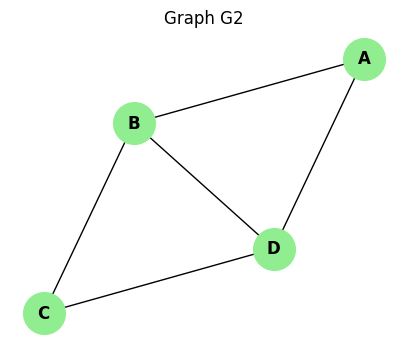

Has Euler Path : True
Has Euler Circuit : False

Euler Path:
[('B', 'A'), ('A', 'D'), ('D', 'B'), ('B', 'C'), ('C', 'D')]


In [ ]:
G2 = nx.Graph()

edges = [
    ("A","B"),
    ("A","D"),
    ("B","C"),
    ("C","D"),
    ("B","D")
]

G2.add_edges_from(edges)

plt.figure(figsize=(5,4))
pos = nx.spring_layout(G2, seed=4)

nx.draw_networkx(
    G2,
    pos,
    node_color="lightgreen",
    node_size=900,
    font_weight="bold"
)

plt.title("Graph G2")
plt.axis("off")
plt.show()

print("Has Euler Path :", nx.has_eulerian_path(G2))
print("Has Euler Circuit :", nx.is_eulerian(G2))

print("\nEuler Path:")
print(list(nx.eulerian_path(G2)))

#### Neither Euler Path nor Euler Circuit

This graph has four odd-degree vertices.

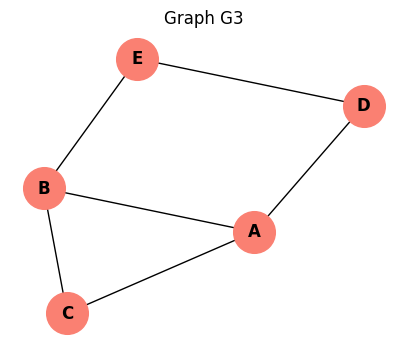

Has Euler Path : True
Has Euler Circuit : False


In [ ]:
G3 = nx.Graph()

edges = [
    ("A","B"),
    ("A","C"),
    ("A","D"),
    ("B","C"),
    ("B","E"),
    ("D","E")
]

G3.add_edges_from(edges)

plt.figure(figsize=(5,4))
pos = nx.spring_layout(G3, seed=6)

nx.draw_networkx(
    G3,
    pos,
    node_color="salmon",
    node_size=900,
    font_weight="bold"
)

plt.title("Graph G3")
plt.axis("off")
plt.show()

print("Has Euler Path :", nx.has_eulerian_path(G3))
print("Has Euler Circuit :", nx.is_eulerian(G3))

#### Directed Graph with an Euler Circuit

For directed graphs, every vertex must satisfy:

- **In-degree = Out-degree**
- The graph is strongly connected (ignoring isolated vertices).

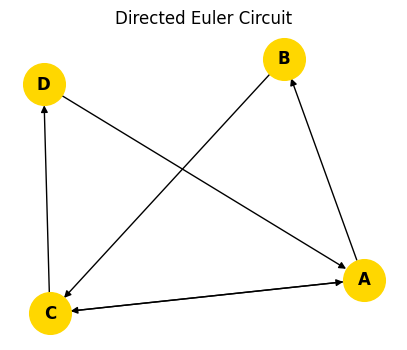

Has Euler Path    : True
Has Euler Circuit : True
Euler Path:
[('A', 'B'), ('B', 'C'), ('C', 'D'), ('D', 'A'), ('A', 'C'), ('C', 'A')]
Euler Circuit:
[('A', 'B'), ('B', 'C'), ('C', 'D'), ('D', 'A'), ('A', 'C'), ('C', 'A')]


In [ ]:
DG = nx.DiGraph()

edges = [
    ("A","B"),
    ("B","C"),
    ("C","D"),
    ("D","A"),
    ("A","C"),
    ("C","A")
]

DG.add_edges_from(edges)

plt.figure(figsize=(5,4))
pos = nx.spring_layout(DG, seed=2)

nx.draw_networkx(
    DG,
    pos,
    node_color="gold",
    node_size=900,
    arrows=True,
    font_weight="bold"
)

plt.title("Directed Euler Circuit")
plt.axis("off")
plt.show()

print("Has Euler Path    :", nx.has_eulerian_path(DG))
print("Has Euler Circuit :", nx.is_eulerian(DG))

print("Euler Path:")
print(list(nx.eulerian_path(DG)))

print("Euler Circuit:")
print(list(nx.eulerian_circuit(DG)))

### 11. Hamilton Paths and Circuits

#### Hamilton Path

A **Hamilton Path** is a path in a graph that visits **every vertex exactly once**.

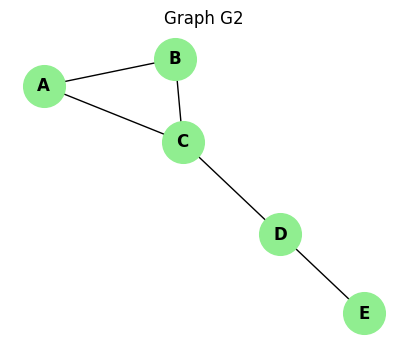

Hamilton Path: ['A', 'B', 'C', 'D', 'E']
Hamilton Circuit: None


In [ ]:
G2 = nx.Graph()

edges = [
    ("A","B"),
    ("B","C"),
    ("C","D"),
    ("D","E"),
    ("A","C")
]

G2.add_edges_from(edges)

plt.figure(figsize=(5,4))
pos = nx.spring_layout(G2, seed=5)

nx.draw_networkx(
    G2,
    pos,
    node_color="lightgreen",
    node_size=900,
    font_weight="bold"
)

plt.title("Graph G2")
plt.axis("off")
plt.show()

hamilton_path = ["A","B","C","D","E"]

print("Hamilton Path:", hamilton_path)
print("Hamilton Circuit: None")

#### Hamilton Circuit

A **Hamilton Circuit** (or Hamilton Cycle) is a Hamilton path that returns to its starting vertex.

If a graph has a Hamilton Circuit, then it automatically has a Hamilton Path. However, a graph may contain a Hamilton Path without containing a Hamilton Circuit.

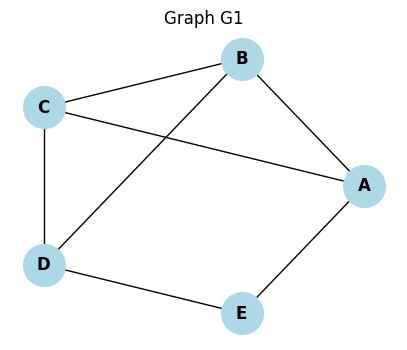

Hamilton Circuit: ['A', 'B', 'C', 'D', 'E', 'A']


In [ ]:
G1 = nx.Graph()

edges = [
    ("A","B"),
    ("B","C"),
    ("C","D"),
    ("D","E"),
    ("E","A"),
    ("A","C"),
    ("B","D")
]

G1.add_edges_from(edges)

plt.figure(figsize=(5,4))
pos = nx.circular_layout(G1)

nx.draw_networkx(
    G1,
    pos,
    node_color="lightblue",
    node_size=900,
    font_weight="bold"
)

plt.title("Graph G1")
plt.axis("off")
plt.show()

hamilton_circuit = ["A","B","C","D","E","A"]
print("Hamilton Circuit:", hamilton_circuit)

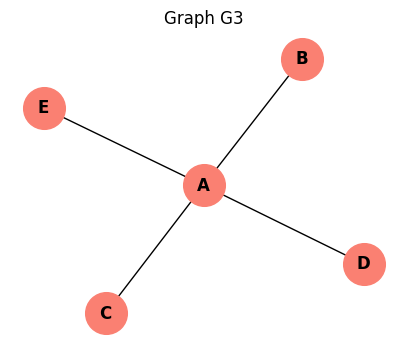

Hamilton Path: None
Hamilton Circuit: None


In [ ]:
# The following graph has no Hamilton path
# because the central vertex must be revisited to reach every leaf.

G3 = nx.Graph()

edges = [
    ("A","B"),
    ("A","C"),
    ("A","D"),
    ("A","E")
]

G3.add_edges_from(edges)

plt.figure(figsize=(5,4))
pos = nx.spring_layout(G3, seed=4)

nx.draw_networkx(
    G3,
    pos,
    node_color="salmon",
    node_size=900,
    font_weight="bold"
)

plt.title("Graph G3")
plt.axis("off")
plt.show()

print("Hamilton Path: None")
print("Hamilton Circuit: None")

#### Finding a Hamilton Path (Backtracking)

Unlike Euler paths, finding Hamilton paths because can be considered an NP-complete problem. A common approach to find a Hamilton path is to use backtracking.

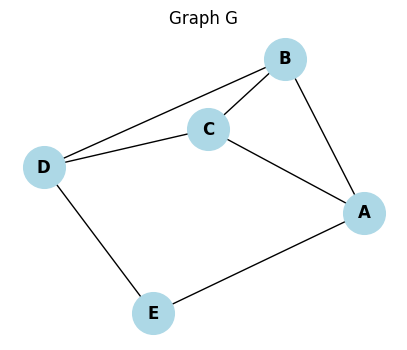

Hamilton Path: ['A', 'B', 'C', 'D', 'E']


In [ ]:
G = nx.Graph()

edges = [
    ("A","B"),
    ("A","E"),
    ("B","C"),
    ("C","D"),
    ("D","E"),
    ("A","C"),
    ("B","D")
]

G.add_edges_from(edges)

def hamilton_path(graph):
    n = len(graph.nodes)

    def dfs(path):
        if len(path) == n:
            return path

        current = path[-1]

        for neighbor in graph.neighbors(current):
            if neighbor not in path:
                result = dfs(path + [neighbor])
                if result:
                    return result

        return None

    for start in graph.nodes:
        result = dfs([start])
        if result:
            return result

    return None

# Display the graph
plt.figure(figsize=(5,4))
pos = nx.spring_layout(G, seed=4)

nx.draw_networkx(
    G,
    pos,
    node_color="lightblue",
    node_size=900,
    font_weight="bold"
)

plt.title("Graph G")
plt.axis("off")
plt.show()

path = hamilton_path(G)
print("Hamilton Path:", path)

##### Finding a Hamilton Circuit (Backtracking)

A Hamilton circuit is obtained by checking whether the last vertex connects back to the starting vertex.

In [ ]:
def hamilton_circuit(graph):
    n = len(graph.nodes)

    def dfs(path):
        if len(path) == n:
            if graph.has_edge(path[-1], path[0]):
                return path + [path[0]]
            return None

        current = path[-1]

        for neighbor in graph.neighbors(current):
            if neighbor not in path:
                result = dfs(path + [neighbor])
                if result:
                    return result
        return None

    for start in graph.nodes:
        result = dfs([start])
        if result:
            return result
    return None

cycle = hamilton_circuit(G)
print("Hamilton Circuit:", cycle)

Hamilton Circuit: ['A', 'B', 'C', 'D', 'E', 'A']


### 12. Connectivity in Graphs

#### Connectivity in an Undirected Graph

An undirected graph is said to be connected if there exists a path between every pair of distinct vertices.

Connected: True


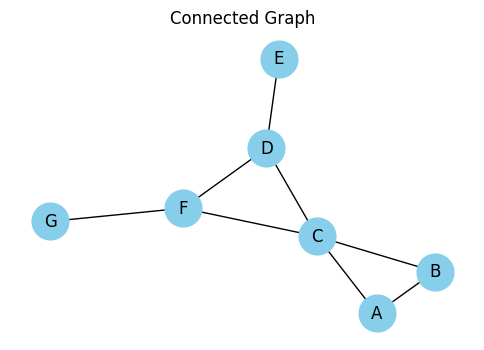

In [ ]:
G = nx.Graph()

G.add_edges_from([
    ("A","B"), ("A","C"),
    ("B","C"), ("B","A"),
    ("C","D"), ("C","F"),
    ("D","C"), ("D","F"), ("D","E"),
    ("F","C"), ("F","D"), ("F","G"),
    ("E","D"), ("G","F")

])

print("Connected:", nx.is_connected(G))

plt.figure(figsize=(6,4))
nx.draw_networkx(G,
                 node_color="skyblue",
                 node_size=700)

plt.title("Connected Graph")
plt.axis("off")
plt.show()

Connected: False


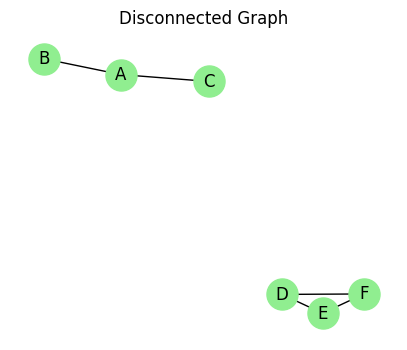

In [ ]:
G = nx.Graph()

G.add_edges_from([
    ("A","B"), ("A","C"),
    ("D","E"), ("D","F"), ("E", "F")
])

print("Connected:", nx.is_connected(G))

plt.figure(figsize=(5,4))
nx.draw_networkx(G,
                 node_color="lightgreen",
                 node_size=500)

plt.title("Disconnected Graph")
plt.axis("off")
plt.show()

#### Connected Components

A **connected component** is a maximal connected subgraph. A connected graph has exactly **one connected component**. A disconnected graph has two or more connected components.

Number of components: 3
Component 1: {'A', 'B', 'C'}
Component 2: {'D', 'E'}
Component 3: {'F', 'G'}


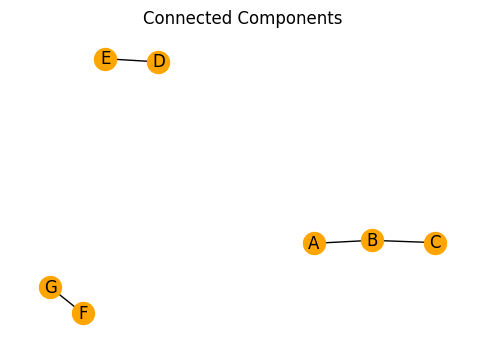

In [ ]:
G = nx.Graph()

G.add_edges_from([
    ("A","B"),
    ("B","C"),
    ("D","E"),
    ("F","G")
])

components = list(nx.connected_components(G))

print("Number of components:", len(components))

for i, comp in enumerate(components, start=1):
    print(f"Component {i}:", comp)

plt.figure(figsize=(6,4))
nx.draw_networkx(G,
                 node_color="orange",
                 node_size=250)

plt.title("Connected Components")
plt.axis("off")
plt.show()

#### Cut Vertices (Articulation Points)

A **cut vertex** (or **articulation point**) is a vertex whose removal increases the number of connected components.

Cut vertices: ['C', 'E', 'B']


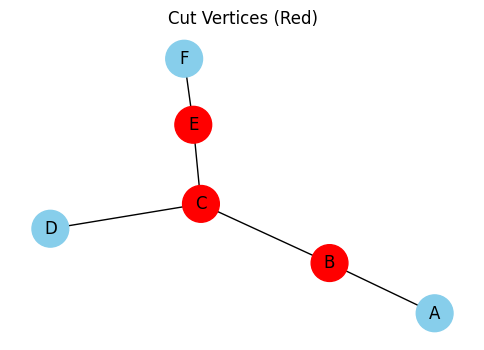

In [ ]:
G = nx.Graph()

G.add_edges_from([
    ("A","B"),
    ("B","C"),
    ("C","D"),
    ("C","E"),
    ("E","F")
])

cut_vertices = list(nx.articulation_points(G))

print("Cut vertices:", cut_vertices)

plt.figure(figsize=(6,4))

colors = [
    "red" if node in cut_vertices else "skyblue"
    for node in G.nodes()
]

nx.draw_networkx(G,
                 node_color=colors,
                 node_size=700)

plt.title("Cut Vertices (Red)")
plt.axis("off")
plt.show()

#### Cut Edges (Bridges)

A **cut edge** (or **bridge**) is an edge whose removal disconnects the graph.

Bridges:
[('A', 'B'), ('B', 'C'), ('C', 'D'), ('C', 'E'), ('E', 'F')]


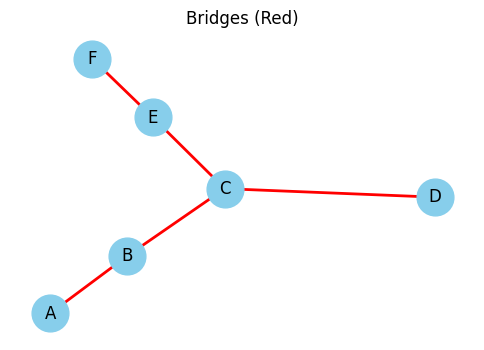

In [ ]:
G = nx.Graph()

G.add_edges_from([
    ("A","B"),
    ("B","C"),
    ("C","D"),
    ("C","E"),
    ("E","F")
])

bridges = list(nx.bridges(G))

print("Bridges:")
print(bridges)

plt.figure(figsize=(6,4))

edge_colors = [
    "red" if edge in bridges or (edge[1], edge[0]) in bridges
    else "black"
    for edge in G.edges()
]

nx.draw_networkx(
    G,
    node_color="skyblue",
    node_size=700,
    edge_color=edge_colors,
    width=2
)

plt.title("Bridges (Red)")
plt.axis("off")
plt.show()

#### Biconnected Graph

A graph is **biconnected** if it is connected, and it contains no cut vertices.

Connected: True
Articulation points: []


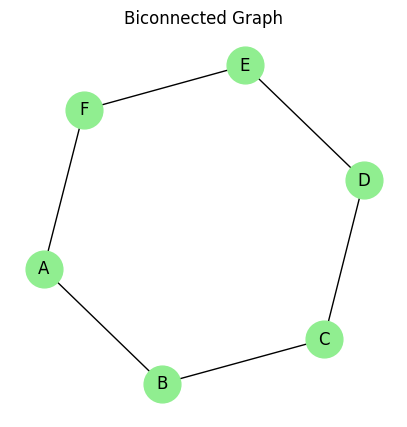

In [ ]:
G = nx.cycle_graph(6)

mapping = {i: chr(65+i) for i in range(6)}
G = nx.relabel_nodes(G, mapping)

print("Connected:", nx.is_connected(G))
print("Articulation points:",
      list(nx.articulation_points(G)))

plt.figure(figsize=(5,5))
nx.draw_networkx(G,
                 node_color="lightgreen",
                 node_size=700)

plt.title("Biconnected Graph")
plt.axis("off")
plt.show()

#### Vertex Connectivity

The **vertex connectivity** of a graph is the minimum number of vertices that must be removed to disconnect the graph.

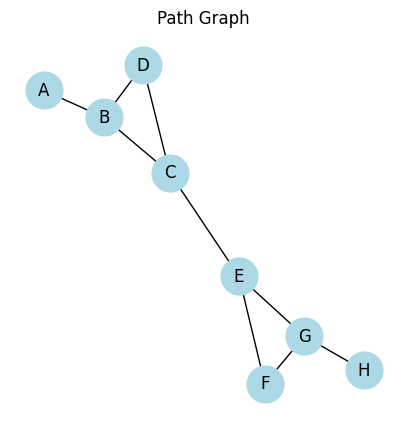

Vertex connectivity: 1


In [ ]:
G = nx.Graph()

G.add_edges_from([
    ("A","B"),
    ("B","D"), ("B", "C"),
    ("C","D"), ("C", "E"),
    ("E","F"), ("E", "G"),
    ("G","F"), ("H", "G")
])

# Show the graph
plt.figure(figsize=(5,5))
nx.draw_networkx(G,
                 node_color="lightblue",
                 node_size=700)

plt.title("Path Graph")
plt.axis("off")
plt.show()

print("Vertex connectivity:",
      nx.node_connectivity(G))

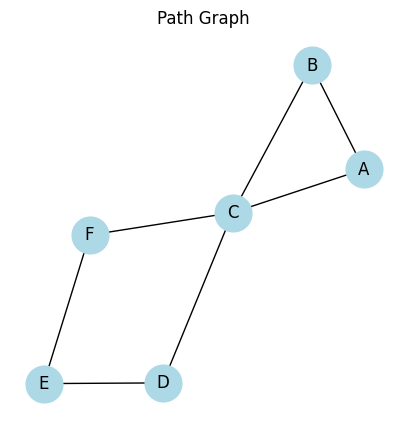

Vertex connectivity: 1


In [ ]:
G = nx.Graph()

G.add_edges_from([
    ("A","B"), ("A", "C"), ("B", "C"),
    ("C","D"), ("C", "F"), ("D", "E"),
    ("E","F")
])

# Show the graph
plt.figure(figsize=(5,5))
nx.draw_networkx(G,
                 node_color="lightblue",
                 node_size=700)

plt.title("Path Graph")
plt.axis("off")
plt.show()

print("Vertex connectivity:",
      nx.node_connectivity(G))

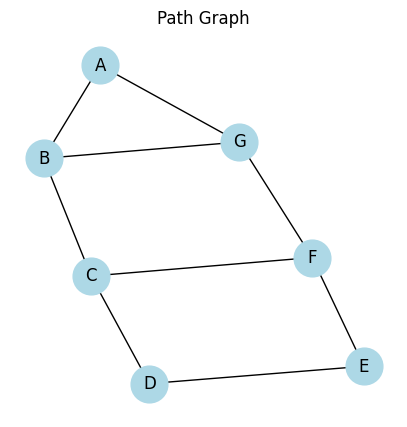

Vertex connectivity: 2


In [ ]:
G = nx.Graph()

G.add_edges_from([
    ("A","B"), ("A", "G"), ("B", "C"), ("B", "G"),
    ("C","D"), ("C", "F"), ("D", "E"),
    ("E","F"), ("G", "F")
])

# Show the graph
plt.figure(figsize=(5,5))
nx.draw_networkx(G,
                 node_color="lightblue",
                 node_size=700)

plt.title("Path Graph")
plt.axis("off")
plt.show()

print("Vertex connectivity:",
      nx.node_connectivity(G))

#### Edge Connectivity

The **edge connectivity** of a graph is the minimum number of edges that must be removed before the graph becomes disconnected.

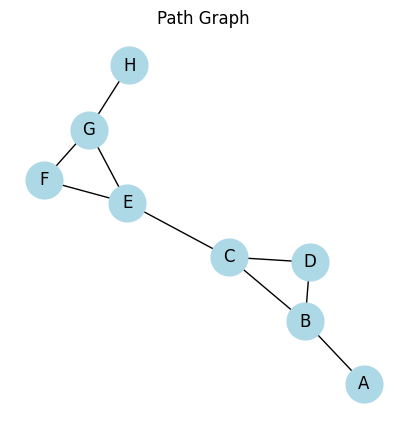

Edge connectivity: 1


In [ ]:
G = nx.Graph()

G.add_edges_from([
    ("A","B"),
    ("B","D"), ("B", "C"),
    ("C","D"), ("C", "E"),
    ("E","F"), ("E", "G"),
    ("G","F"), ("H", "G")
])

# Show the graph
plt.figure(figsize=(5,5))
nx.draw_networkx(G,
                 node_color="lightblue",
                 node_size=700)

plt.title("Path Graph")
plt.axis("off")
plt.show()

print("Edge connectivity:",
      nx.edge_connectivity(G))

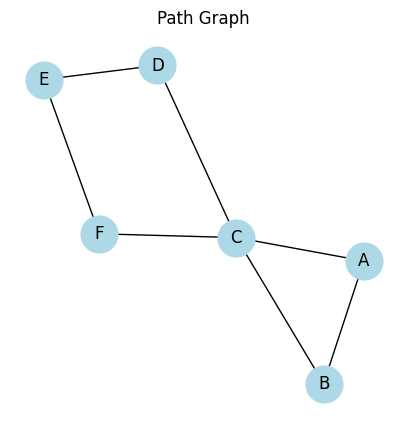

Edge connectivity: 2


In [ ]:
G = nx.Graph()

G.add_edges_from([
    ("A","B"), ("A", "C"), ("B", "C"),
    ("C","D"), ("C", "F"), ("D", "E"),
    ("E","F")
])

# Show the graph
plt.figure(figsize=(5,5))
nx.draw_networkx(G,
                 node_color="lightblue",
                 node_size=700)

plt.title("Path Graph")
plt.axis("off")
plt.show()

print("Edge connectivity:",
      nx.edge_connectivity(G))

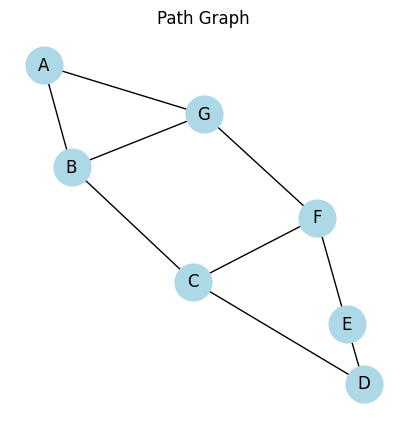

Edge connectivity: 2


In [ ]:
G = nx.Graph()

G.add_edges_from([
    ("A","B"), ("A", "G"), ("B", "C"), ("B", "G"),
    ("C","D"), ("C", "F"), ("D", "E"),
    ("E","F"), ("G", "F")
])

# Show the graph
plt.figure(figsize=(5,5))
nx.draw_networkx(G,
                 node_color="lightblue",
                 node_size=700)

plt.title("Path Graph")
plt.axis("off")
plt.show()

print("Edge connectivity:",
      nx.edge_connectivity(G))

#### Relationship Between Vertex and Edge Connectivity

For any graph, $\kappa(G) \leq \lambda(G) \leq \delta(G)$

Where:

- $(\kappa(G))$  is the **vertex connectivity**,
- $(\lambda(G))$ is the **edge connectivity**, and
- $(\delta(G))$ is the **minimum vertex degree**.

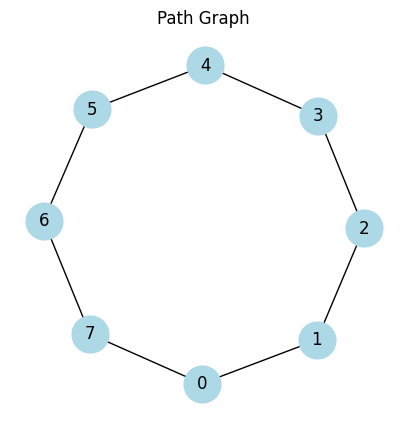

Vertex connectivity : 2
Edge connectivity   : 2
Minimum degree      : 2
True


In [ ]:
G = nx.cycle_graph(8)

# Show the graph
plt.figure(figsize=(5,5))
nx.draw_networkx(G,
                 node_color="lightblue",
                 node_size=700)

plt.title("Path Graph")
plt.axis("off")
plt.show()

k = nx.node_connectivity(G)
lam = nx.edge_connectivity(G)
delta = min(dict(G.degree()).values())

print("Vertex connectivity :", k)
print("Edge connectivity   :", lam)
print("Minimum degree      :", delta)

print(k <= lam <= delta)

#### Connectivity in Directed Graphs

Unlike undirected graphs, **directed graphs** consider the direction of every edge. Therefore, there are two different notions of connectivity depending on whether edge directions are respected.

A directed graph is:

- **Strongly connected** if there exists a directed path between **every pair of vertices**.
- **Weakly connected** if the graph becomes connected after ignoring all edge directions (i.e., treating it as an undirected graph).

Strongly connected : True
Weakly connected   : True


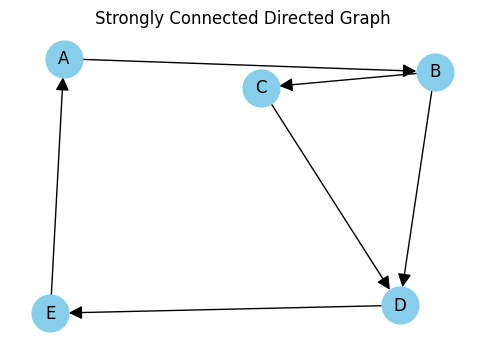

In [ ]:
# Example 1: Strongly Connected Graph
G = nx.DiGraph()

G.add_edges_from([
    ("A","B"),
    ("B","C"),
    ("C","D"),
    ("D","E"),
    ("E","A"),
    ("B","D")
])

print("Strongly connected :", nx.is_strongly_connected(G))
print("Weakly connected   :", nx.is_weakly_connected(G))

plt.figure(figsize=(6,4))
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx(
    G,
    pos,
    node_color="skyblue",
    node_size=700,
    arrows=True,
    arrowsize=20
)

plt.title("Strongly Connected Directed Graph")
plt.axis("off")
plt.show()

Strongly connected : False
Weakly connected   : True


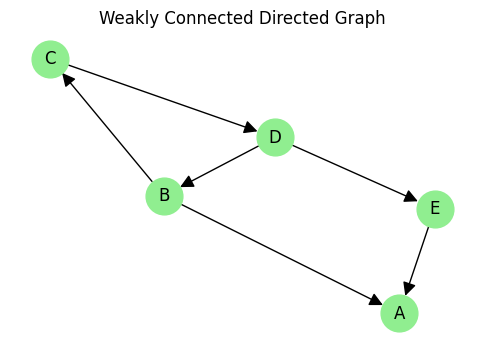

In [ ]:
# Example 2: Weakly Connected but Not Strongly Connected
G = nx.DiGraph()

G.add_edges_from([
    ("B","A"),
    ("B","C"),
    ("C","D"),
    ("D", "B"), ("D","E"),
    ("E", "A")
])

print("Strongly connected :", nx.is_strongly_connected(G))
print("Weakly connected   :", nx.is_weakly_connected(G))

plt.figure(figsize=(6,4))
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx(
    G,
    pos,
    node_color="lightgreen",
    node_size=700,
    arrows=True,
    arrowsize=20
)

plt.title("Weakly Connected Directed Graph")
plt.axis("off")
plt.show()

#### Strongly Connected Components

A **strongly connected component** is a maximal subgraph in which every vertex can reach every other vertex through directed paths.

Strongly Connected Components
Component 1: {'E'}
Component 2: {'D', 'B', 'C'}
Component 3: {'A'}


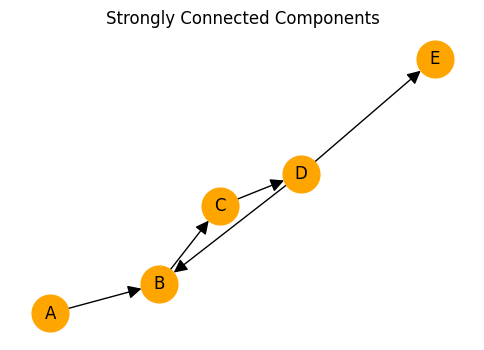

In [ ]:
G = nx.DiGraph()

G.add_edges_from([
    ("A","B"),
    ("B","C"),
    ("C","D"),
    ("D","B"),
    ("D","E")
])

components = list(nx.strongly_connected_components(G))

print("Strongly Connected Components")

for i, comp in enumerate(components, start=1):
    print(f"Component {i}: {comp}")

plt.figure(figsize=(6,4))
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx(
    G,
    pos,
    node_color="orange",
    node_size=700,
    arrows=True,
    arrowsize=20
)

plt.title("Strongly Connected Components")
plt.axis("off")
plt.show()